# Sesión 01: EDA, calidad de datos, preprocesamiento y pipelines


**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran <br>
**Estudiantes:** Isis Catitza Amaya Arbelaez <br>
Santiago Alberto Rozo Silva <br>
Samuel Oviedo Paz <br>
**Fecha:** 2026


[Github](https://github.com/SamuelOviedo2003/ml-embalses-colombia.git)


In [1]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")


Python 3.13.13 instalado correctamente


In [2]:
import sys
!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn category_encoders xgboost catboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 21.5 MB/s eta 0:00:05
   -- ------------------------------------- 7.3/101.7 MB 23.3 MB/s eta 0:00:05
   ----- ---------------------------------- 13.4/101.7 MB 24.9 MB/s eta 0:00:04
   ------- -------------------------------- 18.9/101.7 MB 25.6 MB/s eta 0:00:04
   --------- ------------------------------ 24.1/101.7 MB 25.9 MB/s eta 0:00:03
   ----------- ---------------------------- 29.9/101.7 MB 26.2 MB/s eta 0:00:03
   -------------- ------------------------- 35.7/101.7 MB 26.4 MB/s eta 0:00:03
   ---------------- ----------------------- 41.7/101.7 MB 26.5 MB/s eta 0:00:03
   ------------------ --------------------- 47.2/101.7 MB 26.6 MB/s eta 0:00:03
   -------------------- ------------------- 52.7/101.7 MB 26.7 MB/s eta 0:00:02
   ---------------------- ----------------- 58.5/101.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\saroz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [4]:
# Verificar versiones de librerías críticas
from packaging import version
from sklearn.model_selection import train_test_split
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")


scikit-learn 1.8.0 instalado


In [5]:
def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def summarize_schema(df: pd.DataFrame, target: Optional[str] = None) -> pd.DataFrame:
    """Return a compact schema summary."""
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })
    summary["role"] = "feature"
    if target is not None and target in summary["column"].values:
        summary.loc[summary["column"] == target, "role"] = "target"
    return summary.sort_values(["role", "missing_pct", "column"], ascending=[False, False, True]).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a missing-value summary sorted by missingness."""
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values,
    })
    out = out.sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True)
    return out


def detect_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Return duplicated rows."""
    dup_mask = df.duplicated(keep=False)
    return df.loc[dup_mask].copy()


def iqr_outlier_rate(series: pd.Series) -> float:
    """Return the percentage of IQR-rule outliers for a numeric series."""
    s = series.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)


def numeric_profile(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Return a robust numeric profile for selected columns."""
    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skew": s.skew(),
            "outlier_pct_iqr": iqr_outlier_rate(df[col]),
        })
    return pd.DataFrame(rows).round(3)


def plot_missing_matrix(df: pd.DataFrame, max_rows: int = 250) -> None:
    """Visualize missingness as a compact matrix."""
    sample = df.head(max_rows)
    matrix = sample.isna().astype(int).T.values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_title("Mapa de missingness (columnas × filas)")
    ax.set_xlabel("Filas (muestra inicial)")
    ax.set_ylabel("Columnas")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns)
    ax.set_xticks([])
    plt.tight_layout()
    plt.show()


def plot_missing_bars(df: pd.DataFrame) -> None:
    """Bar plot of missing percentages."""
    miss = missing_summary(df)
    miss = miss[miss["missing"] > 0]
    if miss.empty:
        print("✅ No hay valores faltantes en el dataset de trabajo.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(miss["column"], miss["missing_pct"])
    ax.set_title("Porcentaje de valores faltantes por columna")
    ax.set_ylabel("% faltante")
    ax.set_xlabel("Columna")
    ax.axhline(5, linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_numeric_audit(df: pd.DataFrame, columns: list[str], target: str) -> None:
    """Plot histogram, boxplot, and target scatter for selected numeric columns."""
    for col in columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histograma
        axes[0].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
        axes[0].axvline(df[col].mean(), linestyle="--", linewidth=1, label=f"Media: {df[col].mean():.2f}")
        axes[0].axvline(df[col].median(), linestyle=":", linewidth=1, label=f"Mediana: {df[col].median():.2f}")
        axes[0].set_title(f"Distribución: {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_ylabel(col)

        # Relación con target
        valid = df[[col, target]].dropna()
        axes[2].scatter(valid[col], valid[target], alpha=0.2, s=10)
        axes[2].set_title(f"{col} vs {target}")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)

        plt.tight_layout()
        plt.show()


def plot_categorical_audit(df: pd.DataFrame, cat_col: str, target: str) -> None:
    """Audit a categorical feature."""
    counts = df[cat_col].fillna("MISSING").value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Distribución de categorías: {cat_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    grouped = df[[cat_col, target]].copy()
    grouped[cat_col] = grouped[cat_col].fillna("MISSING")
    category_order = counts.index.astype(str).tolist()

    data_for_box = [
        grouped.loc[grouped[cat_col].astype(str) == level, target].dropna().values
        for level in category_order
    ]
    axes[1].boxplot(data_for_box, labels=category_order, patch_artist=True)
    axes[1].set_title(f"{target} por categoría: {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(target)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str]) -> None:
    """Simple correlation heatmap using matplotlib only."""
    corr = df[columns].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Matriz de correlación")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def quick_interpretation(df: pd.DataFrame, target: str, numeric_cols: list[str]) -> None:
    """Print short interpretation cues after EDA."""
    print_section("LECTURA RÁPIDA DEL EDA")
    print(f"- Filas: {df.shape[0]:,}")
    print(f"- Columnas: {df.shape[1]}")
    print(f"- Target: {target}")
    print(f"- Variables numéricas: {len(numeric_cols)}")
    print(f"- Variables categóricas: {df.select_dtypes(exclude=[np.number]).shape[1]}")
    print(f"- Valores faltantes totales: {int(df.isna().sum().sum())}")
    print(f"- Filas duplicadas exactas: {int(df.duplicated().sum())}")


In [6]:
def plot_cross_corr(df, feature, target, max_lag=30):
    lags = range(0, max_lag)
    corrs = [
        df[target].corr(df[feature].shift(lag))
        for lag in lags
    ]

    plt.figure(figsize=(8,4))
    plt.plot(lags, corrs)
    plt.title(f"Cross-correlation: {feature} vs {target}")
    plt.xlabel("Lag (días)")
    plt.ylabel("Correlación")
    plt.axhline(0)
    plt.show()


In [7]:
def plot_lag_scatter(df, feature, target, lag=7):
    plt.figure(figsize=(5,5))
    plt.scatter(df[feature].shift(lag), df[target], alpha=0.3)
    plt.xlabel(f"{feature} (lag {lag})")
    plt.ylabel(target)
    plt.title(f"{feature}_lag{lag} vs {target}")
    plt.show()


In [8]:
def plot_time_series(df, feature, embalse):
    data = df[df["CodigoEmbalse"] == embalse]

    plt.figure(figsize=(10,4))
    plt.plot(data["Fecha"], data["reserva_pct"], label="reserva")
    plt.plot(data["Fecha"], data[feature], label=feature, alpha=0.7)
    plt.legend()
    plt.title(f"{feature} vs reserva - {embalse}")
    plt.show()


In [9]:
import seaborn as sns

def lag_corr_matrix(df, feature, target, max_lag=15):
    data = {
        f"{feature}_lag_{lag}": df[feature].shift(lag)
        for lag in range(1, max_lag)
    }
    lag_df = pd.DataFrame(data)
    lag_df[target] = df[target]

    corr = lag_df.corr()

    plt.figure(figsize=(6,6))
    sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), annot=True, cmap="coolwarm")
    plt.title(f"Lag correlation: {feature}")
    plt.show()


In [10]:
# Ruta al dataset
data_path = Path("Datasets/dataset_final.csv")

# Cargar dataset
embalses = pd.read_csv(data_path)

# Definir target
TARGET = "reserva_pct" 

# Filtrado de datos
embalses = embalses[
    ~embalses['CodigoEmbalse'].isin([
        'AGREGADO_SIN',
        'ITUANGO',
        'SOGAMOSO',
        "ELQUIMBO"
    ])
]


embalses["Fecha"] = pd.to_datetime(embalses["Fecha"])


print(f"✅ Dataset cargado desde: {data_path}")
print(f"✅ Shape: {embalses.shape[0]:,} filas × {embalses.shape[1]} columnas")


✅ Dataset cargado desde: Datasets\dataset_final.csv
✅ Shape: 92,043 filas × 18 columnas


In [11]:
print_section("PRIMERA INSPECCIÓN")

display(embalses.head())

print("\nTipos de datos:")
display(embalses.dtypes.to_frame(name="dtype").T)

print("\nDescripción numérica rápida:")
display(embalses.describe(include=[np.number]).T)



                                   PRIMERA INSPECCIÓN                                   


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino12_proxy,oni_anom,tp,ro,sro,swvl1,wind_speed
0,2013-01-01,AGREGADO_BOGOTA,Centro,78.07,230740000.0,337530000.0,68.361331,15.080780,-1.319832,0.388092,1016.10016,23.663086,-0.29,0.000596,0.024259,0.000089,0.278295,1.375708
1,2013-01-01,ALTOANCH,Valle,42.61,131910000.0,251100000.0,52.532855,25.506561,0.026604,0.779938,1009.99140,23.663086,-0.29,0.550508,0.380278,0.037938,0.500181,0.780391
2,2013-01-01,BETANIA,Centro,79.99,230740000.0,337530000.0,68.361331,22.812714,1.079582,0.876373,1011.49200,23.663086,-0.29,0.000477,0.004232,0.000000,0.327062,1.390513
3,2013-01-01,CALIMA1,Valle,75.15,131910000.0,251100000.0,52.532855,18.804901,0.891106,-0.748627,1013.66266,23.663086,-0.29,0.626683,0.474691,0.307947,0.470689,1.163835
4,2013-01-01,CHUZA,Oriente,64.33,29590000.0,37190000.0,79.564399,12.801971,-2.053474,0.732819,1016.85516,23.663086,-0.29,0.000119,0.006855,0.000030,0.269834,2.180317



Tipos de datos:


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,t2m,u10,v10,msl,sst_nino12_proxy,oni_anom,tp,ro,sro,swvl1,wind_speed
dtype,datetime64[us],str,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64



Descripción numérica rápida:


,count,mean,std,min,25%,50%,75%,max
reserva_pct,92043.0,6.233165e+01,2.525805e+01,-1.850000,4.391000e+01,6.346000e+01,8.261000e+01,1.243900e+02
aportes_masa,92043.0,4.609087e+08,5.168267e+08,0.000000,1.727945e+08,2.959080e+08,5.413445e+08,5.932676e+09
media_historica_masa,92043.0,4.987097e+08,4.531687e+08,0.000000,2.258800e+08,3.380000e+08,5.548600e+08,2.871090e+09
aportes_vs_media_pct,92001.0,9.165685e+01,4.818641e+01,5.807358,6.108944e+01,8.167629e+01,1.105658e+02,1.251948e+03
t2m,92043.0,2.079844e+01,4.426639e+00,10.396088,1.746185e+01,2.000095e+01,2.451419e+01,3.275363e+01
u10,92043.0,-9.793757e-02,6.427891e-01,-3.179215,-4.481869e-01,-9.420776e-02,2.592964e-01,2.942589e+00
v10,92043.0,7.188181e-02,5.434391e-01,-2.124630,-2.563763e-01,3.868890e-02,3.588963e-01,3.199093e+00
msl,92043.0,1.013775e+03,2.680938e+00,1004.449500,1.011703e+03,1.013814e+03,1.015775e+03,1.022905e+03
sst_nino12_proxy,92043.0,2.332471e+01,2.057107e+00,18.682465,2.174027e+01,2.320346e+01,2.467938e+01,2.893881e+01
oni_anom,92043.0,1.736619e-01,8.828499e-01,-1.200000,-4.500000e-01,0.000000e+00,6.500000e-01,2.750000e+00


In [12]:
# Definir target correcto
TARGET = "reserva_pct"  # según tu tabla

# Ejecutar resumen de esquema
schema_df = summarize_schema(embalses, target=TARGET)

print_section("SCHEMA SUMMARY")
display(schema_df)



                                     SCHEMA SUMMARY                                     


,column,dtype,non_null,missing,missing_pct,n_unique,role
0,reserva_pct,float64,92043,0,0.00,10995,target
1,aportes_vs_media_pct,float64,92001,42,0.05,26239,feature
2,CodigoEmbalse,str,92043,0,0.00,21,feature
3,Fecha,datetime64[us],92043,0,0.00,4383,feature
4,RegionHidrologica,str,92043,0,0.00,6,feature
5,aportes_masa,float64,92043,0,0.00,24480,feature
6,media_historica_masa,float64,92043,0,0.00,854,feature
7,msl,float64,92043,0,0.00,46825,feature
8,oni_anom,float64,92043,0,0.00,109,feature
9,ro,float64,92043,0,0.00,12731,feature


In [13]:
print_section("SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES")

feature_cols = [col for col in embalses.columns if col != TARGET]
numeric_cols = embalses[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = embalses[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target: {TARGET}")
print(f"Número de features: {len(feature_cols)}")
print(f"Features numéricas: {numeric_cols}")
print(f"Features categóricas: {categorical_cols}")



                       SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES                        
Target: reserva_pct
Número de features: 17
Features numéricas: ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed']
Features categóricas: ['Fecha', 'CodigoEmbalse', 'RegionHidrologica']


In [14]:
print_section("INTEGRIDAD BÁSICA")

duplicated_rows = detect_duplicate_rows(embalses)
print(f"Filas duplicadas exactas: {embalses.duplicated().sum()}")

low_cardinality_numeric = [
    col for col in numeric_cols
    if embalses[col].nunique(dropna=True) <= 10
]
print(f"Variables numéricas con baja cardinalidad: {low_cardinality_numeric}")

high_cardinality_categorical = [
    col for col in categorical_cols
    if embalses[col].nunique(dropna=True) > 20
]
print(f"Variables categóricas con cardinalidad alta: {high_cardinality_categorical}")

if not duplicated_rows.empty:
    print("\nEjemplo de duplicados detectados:")
    display(duplicated_rows.head())



                                   INTEGRIDAD BÁSICA                                    
Filas duplicadas exactas: 0
Variables numéricas con baja cardinalidad: []
Variables categóricas con cardinalidad alta: ['Fecha', 'CodigoEmbalse']


In [15]:
miss_df = missing_summary(embalses)
print_section("RESUMEN DE VALORES FALTANTES")
display(miss_df)



                              RESUMEN DE VALORES FALTANTES                              


,column,missing,missing_pct,dtype
0,aportes_vs_media_pct,42,0.05,float64
1,CodigoEmbalse,0,0.00,str
2,Fecha,0,0.00,datetime64[us]
3,RegionHidrologica,0,0.00,str
4,aportes_masa,0,0.00,float64
5,media_historica_masa,0,0.00,float64
6,msl,0,0.00,float64
7,oni_anom,0,0.00,float64
8,reserva_pct,0,0.00,float64
9,ro,0,0.00,float64


In [16]:
selected_numeric_for_audit = [
    col for col in [
        "aportes_masa",
        "media_historica_masa",
        "aportes_vs_media_pct",
        "t2m",
        "u10",
        "v10",
        "msl",
        "sst_nino",
        "tp",
        "ro",
        "sro",
        "swvl1",
        "wind_speed"
    ]
    if col in embalses.columns
]

numeric_profile_df = numeric_profile(embalses, selected_numeric_for_audit)

print_section("PERFIL NUMÉRICO ROBUSTO (FEATURES)")
display(numeric_profile_df)



                           PERFIL NUMÉRICO ROBUSTO (FEATURES)                           


,column,mean,median,std,min,q1,q3,max,skew,outlier_pct_iqr
0,aportes_masa,4.609087e+08,2.959080e+08,5.168267e+08,0.000,1.727945e+08,5.413445e+08,5.932676e+09,3.161,8.98
1,media_historica_masa,4.987097e+08,3.380000e+08,4.531687e+08,0.000,2.258800e+08,5.548600e+08,2.871090e+09,1.990,14.13
2,aportes_vs_media_pct,9.165700e+01,8.167600e+01,4.818600e+01,5.807,6.108900e+01,1.105660e+02,1.251948e+03,3.897,3.95
3,t2m,2.079800e+01,2.000100e+01,4.427000e+00,10.396,1.746200e+01,2.451400e+01,3.275400e+01,0.125,0.00
4,u10,-9.800000e-02,-9.400000e-02,6.430000e-01,-3.179,-4.480000e-01,2.590000e-01,2.943000e+00,-0.194,4.07
5,v10,7.200000e-02,3.900000e-02,5.430000e-01,-2.125,-2.560000e-01,3.590000e-01,3.199000e+00,0.479,3.32
6,msl,1.013775e+03,1.013814e+03,2.681000e+00,1004.450,1.011703e+03,1.015775e+03,1.022905e+03,0.015,0.03
7,tp,2.710000e-01,1.000000e-01,5.220000e-01,0.000,2.000000e-02,3.190000e-01,1.623800e+01,7.092,8.68
8,ro,1.580000e-01,6.100000e-02,4.160000e-01,0.000,1.700000e-02,1.610000e-01,1.659900e+01,12.136,8.94
9,sro,7.600000e-02,1.100000e-02,2.250000e-01,0.000,1.000000e-03,6.600000e-02,1.078900e+01,12.767,12.13


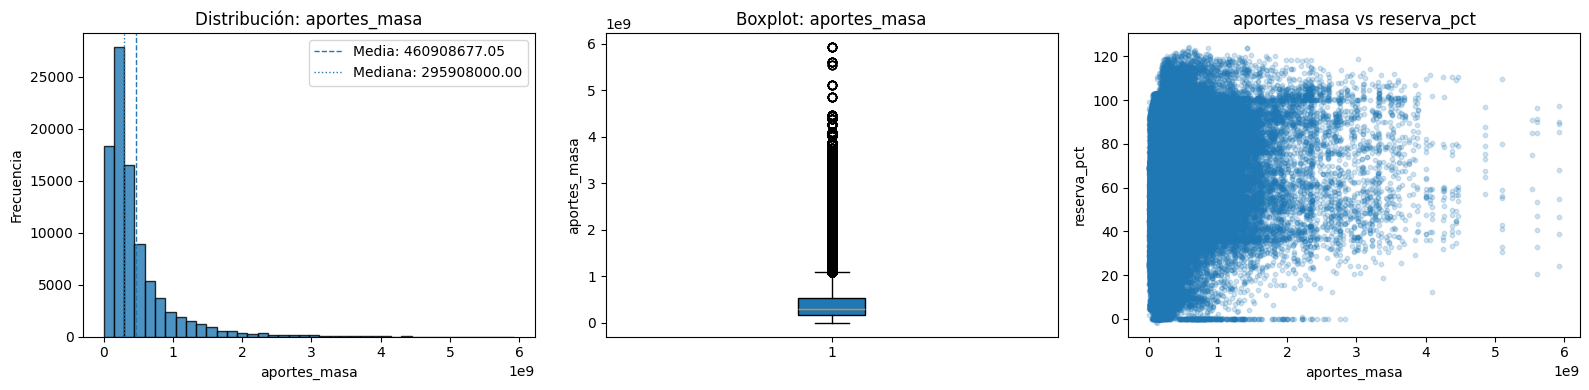

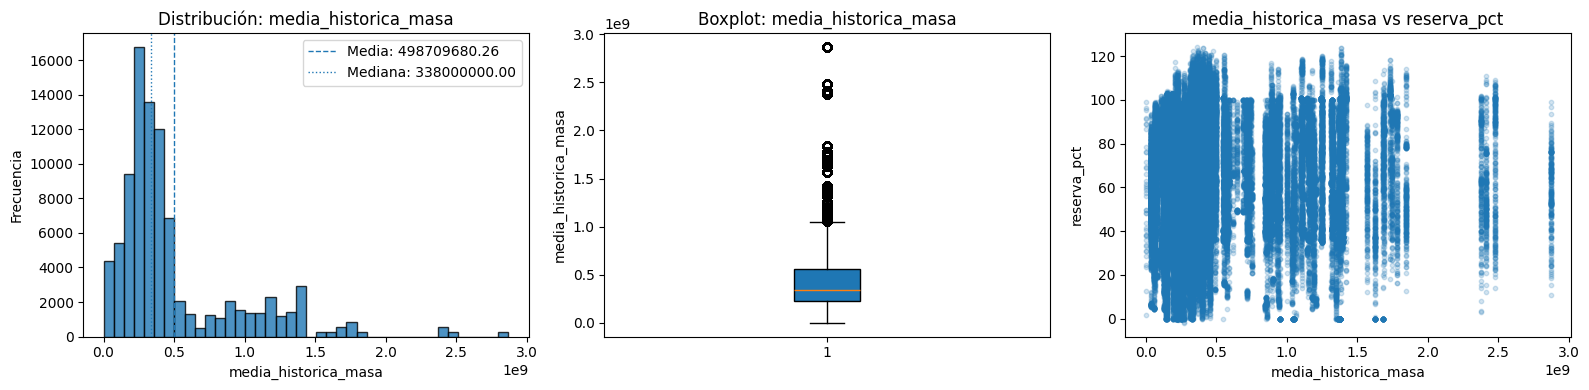

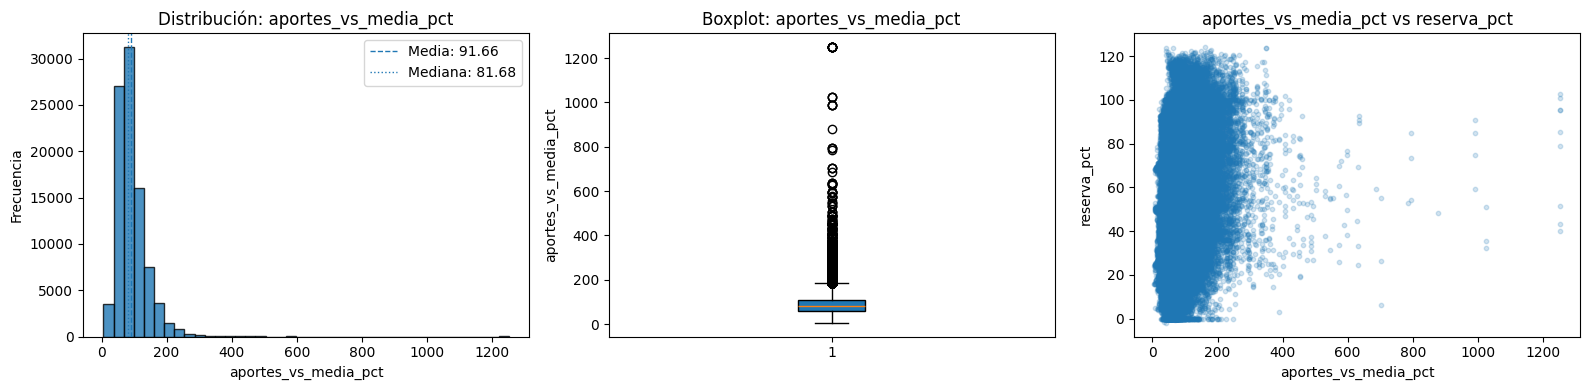

In [17]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "aportes_masa",
            "media_historica_masa",
            "aportes_vs_media_pct"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


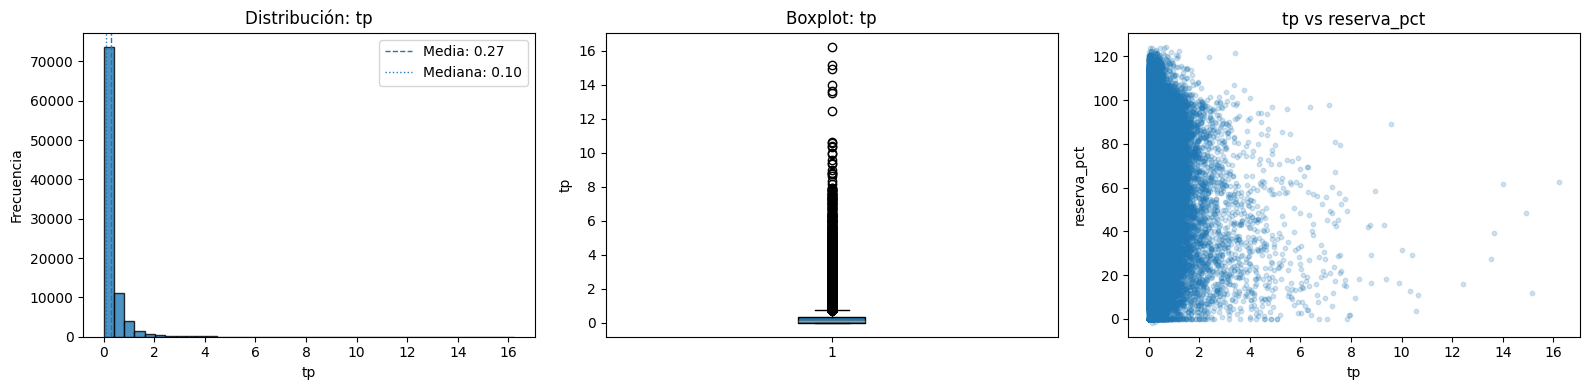

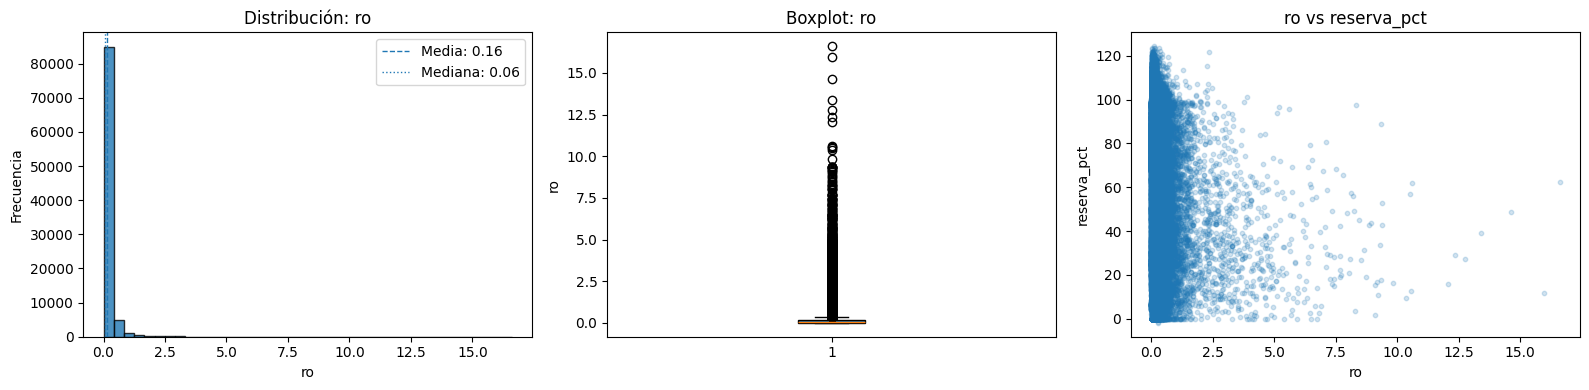

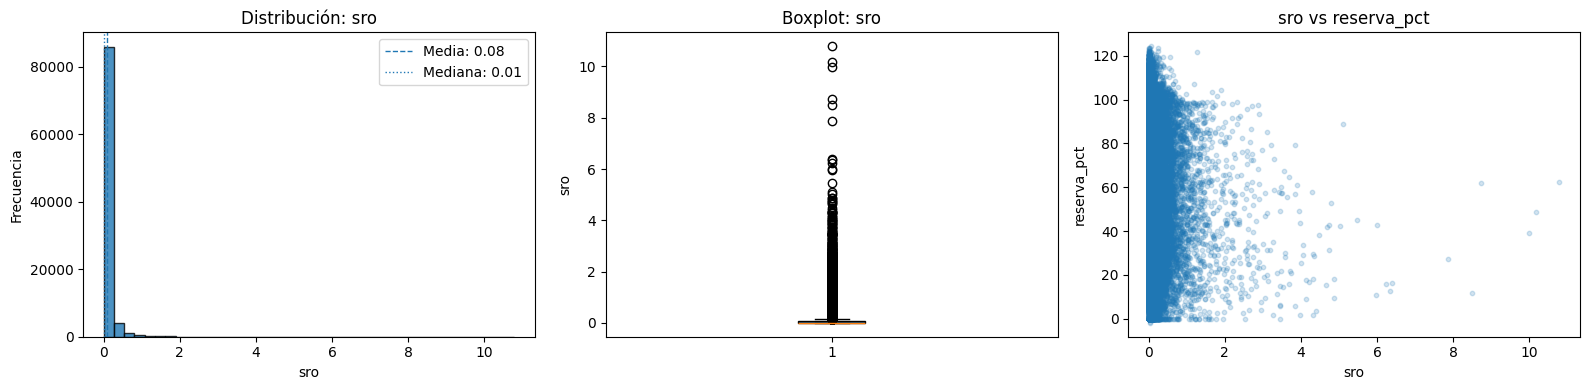

In [18]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "tp",
            "ro",
            "sro"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


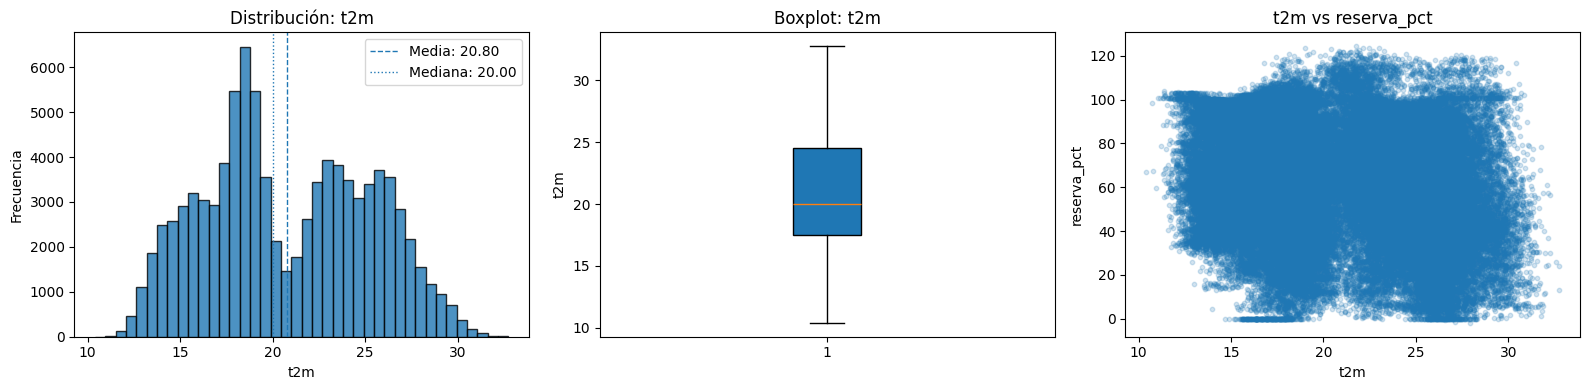

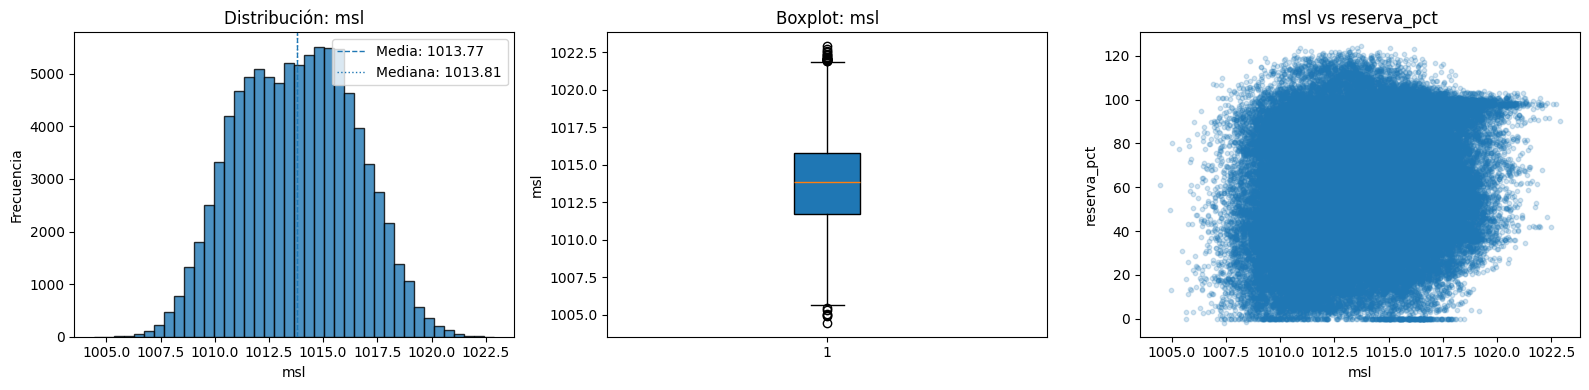

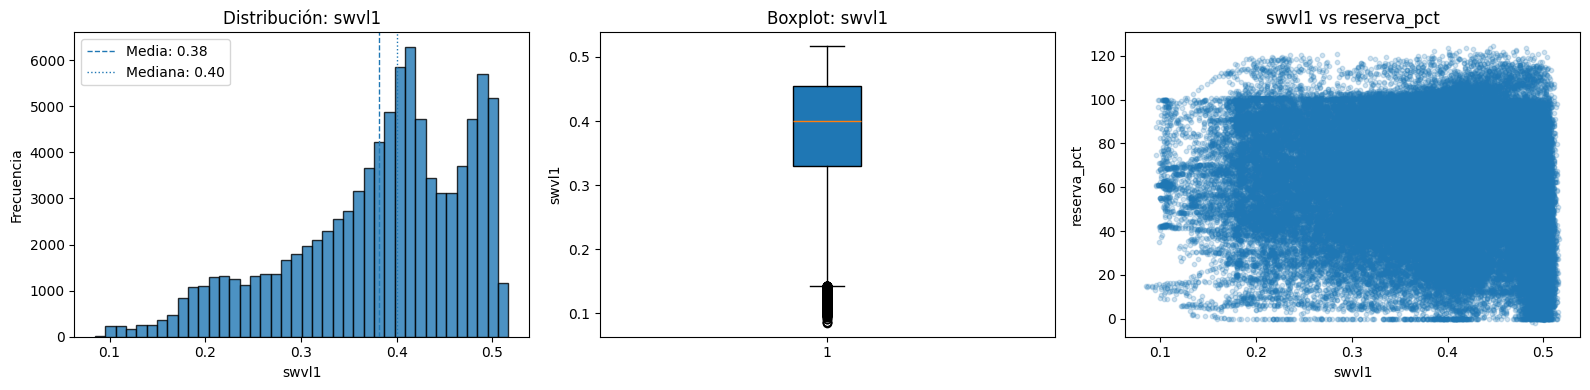

In [19]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "t2m",
            "msl",
            "swvl1"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


In [20]:
plot_numeric_audit(
    embalses,
    columns=[
        col for col in [
            "sst_nino"
        ] if col in embalses.columns
    ],
    target="reserva_pct",
)


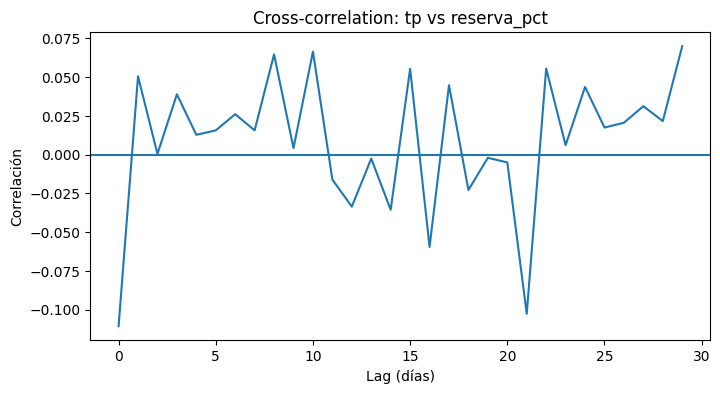

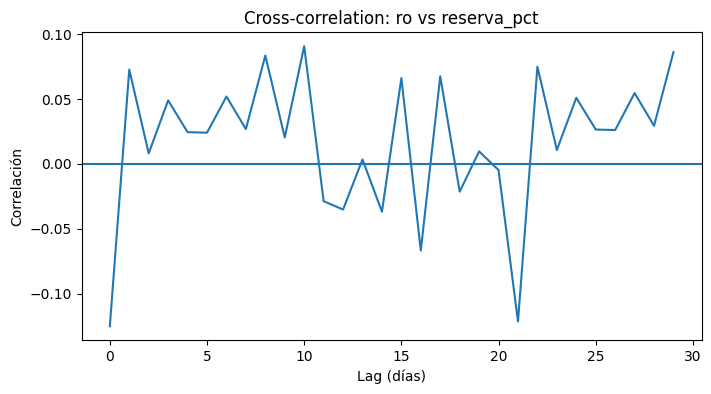

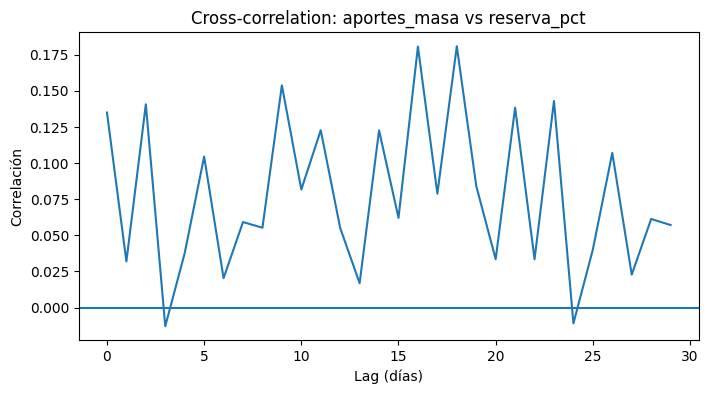

In [21]:
plot_cross_corr(embalses, "tp", "reserva_pct")
plot_cross_corr(embalses, "ro", "reserva_pct")
plot_cross_corr(embalses, "aportes_masa", "reserva_pct")


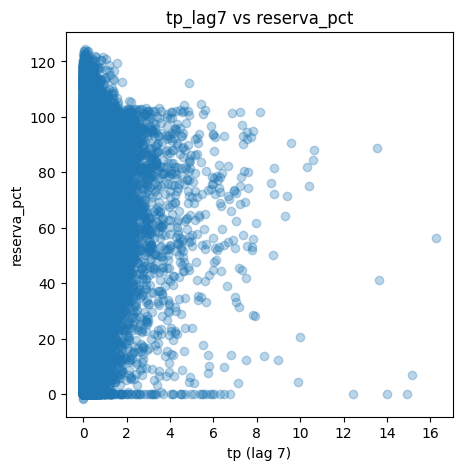

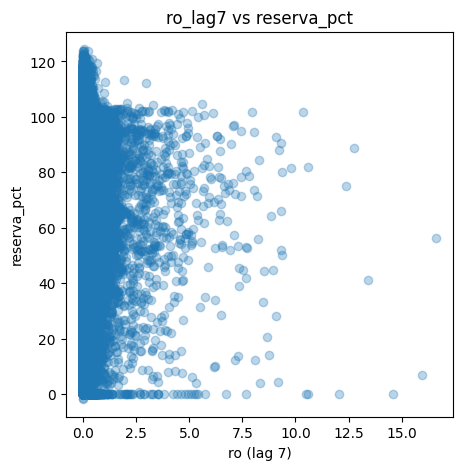

In [22]:
plot_lag_scatter(embalses, "tp", "reserva_pct", lag=7)
plot_lag_scatter(embalses, "ro", "reserva_pct", lag=7)


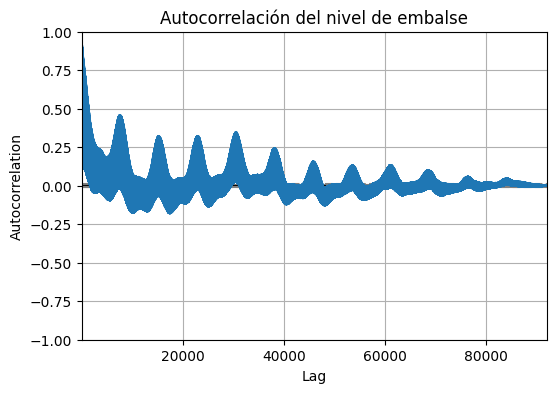

In [23]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(6,4))
autocorrelation_plot(embalses["reserva_pct"])
plt.title("Autocorrelación del nivel de embalse")
plt.show()


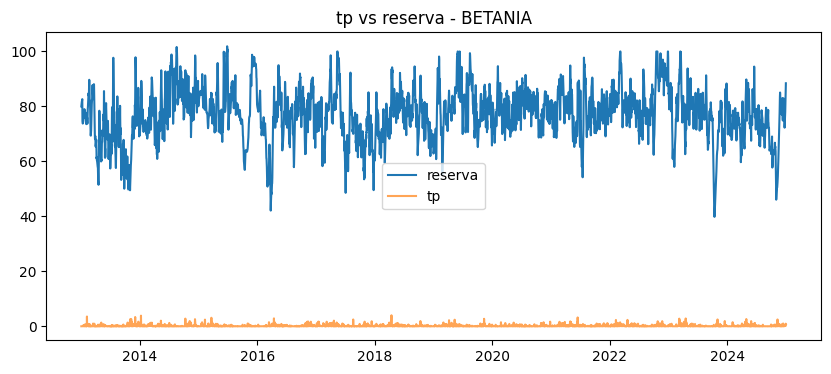

In [24]:
plot_time_series(embalses, "tp", "BETANIA")


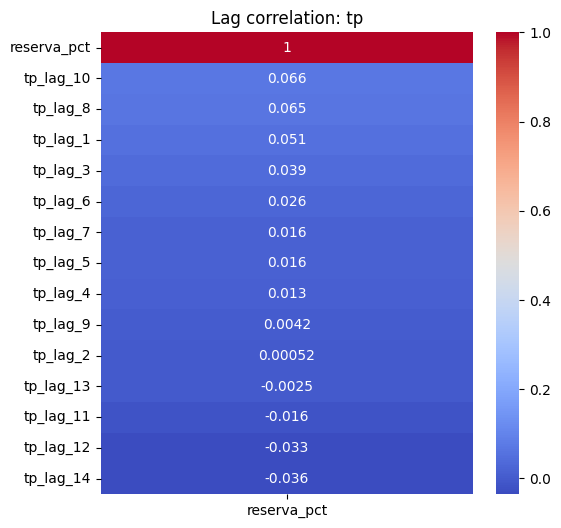

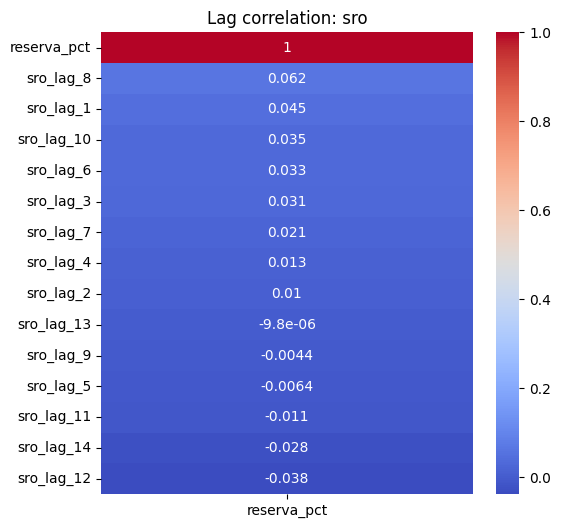

In [25]:
lag_corr_matrix(embalses, "tp", "reserva_pct")
lag_corr_matrix(embalses, "sro", "reserva_pct")


In [26]:
quick_interpretation(embalses, target=TARGET, numeric_cols=numeric_cols)



                                 LECTURA RÁPIDA DEL EDA                                 
- Filas: 92,043
- Columnas: 18
- Target: reserva_pct
- Variables numéricas: 14
- Variables categóricas: 3
- Valores faltantes totales: 42
- Filas duplicadas exactas: 0


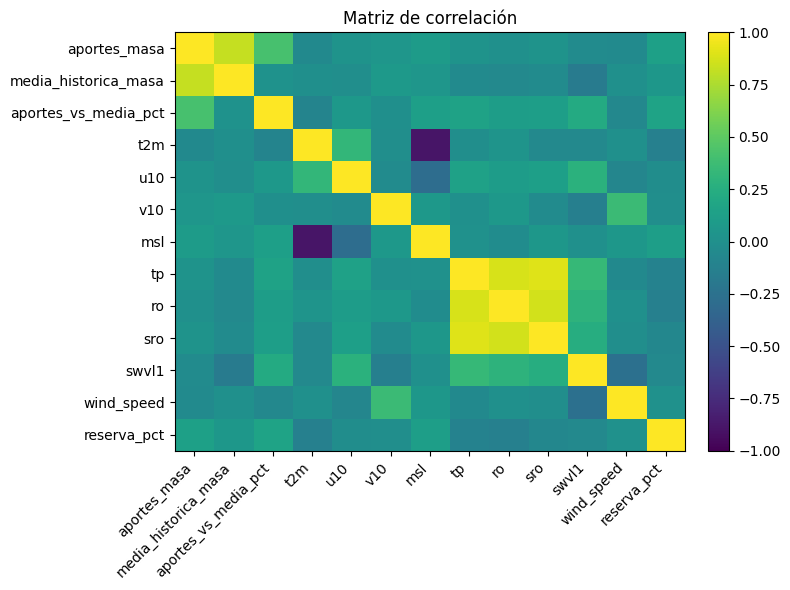

In [27]:
# Variables numéricas a analizar
selected_numeric_for_audit = [
    "aportes_masa",
    "media_historica_masa",
    "aportes_vs_media_pct",
    "t2m",
    "u10",
    "v10",
    "msl",
    "sst_nino",
    "tp",
    "ro",
    "sro",
    "swvl1",
    "wind_speed",
    "reserva_pct"
]
 
# Filtrar solo columnas existentes
selected_numeric_for_audit = [
    col for col in selected_numeric_for_audit
    if col in embalses.columns
]
 
# Invocar función
plot_correlation_heatmap(
    embalses,
    selected_numeric_for_audit
)


In [28]:
target_corr = (
    embalses[selected_numeric_for_audit]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
    .drop(TARGET)
    .to_frame(name="corr_with_target")
)

print_section("CORRELACIÓN CON EL TARGET")
display(target_corr)



                               CORRELACIÓN CON EL TARGET                                


,corr_with_target
aportes_vs_media_pct,0.162550
aportes_masa,0.134950
msl,0.120296
media_historica_masa,0.061888
wind_speed,0.013968
v10,-0.014424
u10,-0.020599
swvl1,-0.059871
sro,-0.077481
tp,-0.110561


## Outliers


In [29]:
# =========================================================
# FILTRADO DE OUTLIERS FÍSICAMENTE IMPOSIBLES
# =========================================================

print("=" * 60)
print("ANTES DEL FILTRADO")
print("=" * 60)

print(f"Cantidad de registros: {len(embalses):,}")

# =========================================================
# CONDICIONES FÍSICAS VÁLIDAS
# =========================================================

valid_mask = (
    # precipitación no negativa
    (embalses["tp"] >= 0)

    # humedad del suelo no negativa
    & (embalses["swvl1"] >= 0)

    # presión atmosférica razonable
    & (embalses["msl"] >= 850)
    & (embalses["msl"] <= 1100)

    # velocidad del viento no negativa
    & (embalses["wind_speed"] >= 0)

    # porcentaje de reserva razonable
    & (embalses["reserva_pct"] >= 0)
    & (embalses["reserva_pct"] <= 120)
)

# =========================================================
# FILTRAR DATASET
# =========================================================

df_filtered = embalses[valid_mask].copy()

# =========================================================
# RESULTADOS
# =========================================================

print("\n" + "=" * 60)
print("DESPUÉS DEL FILTRADO")
print("=" * 60)

print(f"Cantidad de registros: {len(df_filtered):,}")

removed = len(embalses) - len(df_filtered)

print(f"\nRegistros eliminados: {removed:,}")


ANTES DEL FILTRADO
Cantidad de registros: 92,043

DESPUÉS DEL FILTRADO
Cantidad de registros: 91,992

Registros eliminados: 51


## Split


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [31]:
SEED = 72


In [32]:
#embalses = embalses.drop(columns=["aportes_vs_media_pct"])

In [33]:
embalses = embalses.sort_values("Fecha")
base_feature_cols = [col for col in embalses.columns if col != TARGET]

X_full = embalses[base_feature_cols].copy()
y_full = embalses[TARGET].copy()

split_idx = int(len(X_full) * 0.8)

X_train_raw = X_full.iloc[:split_idx]
X_test_raw  = X_full.iloc[split_idx:]

y_train = y_full.iloc[:split_idx]
y_test  = y_full.iloc[split_idx:]

print_section("PARTICIÓN DE DATOS")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")
print(f"Target mean (train): {y_train.mean():,.3f}")
print(f"Target mean (test):  {y_test.mean():,.3f}")


                                   PARTICIÓN DE DATOS                                   
Train shape: (73634, 17)
Test shape:  (18409, 17)
Target mean (train): 62.488
Target mean (test):  61.708


## Feature engineering


In [34]:
import numpy as np
import pandas as pd

# =========================================================
# ORDEN TEMPORAL
# =========================================================

X_train_raw = X_train_raw.sort_values(
    ["CodigoEmbalse", "Fecha"]
).copy()

X_test_raw = X_test_raw.sort_values(
    ["CodigoEmbalse", "Fecha"]
).copy()

# =========================================================
# HELPERS
# =========================================================

def rolling_mean(series, window):
    return (
        series
        .shift(1)
        .rolling(window, min_periods=1)
        .mean()
    )

def rolling_std(series, window):
    return (
        series
        .shift(1)
        .rolling(window, min_periods=2)
        .std()
    )

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:

    out = df.copy()

    # =====================================================
    # FEATURES TEMPORALES
    # =====================================================

    out["month"] = out["Fecha"].dt.month
    out["dayofyear"] = out["Fecha"].dt.dayofyear

    # =====================================================
    # FEATURES CÍCLICAS
    # =====================================================

    out["month_sin"] = np.sin(
        2 * np.pi * out["month"] / 12
    )

    out["month_cos"] = np.cos(
        2 * np.pi * out["month"] / 12
    )

    out["day_sin"] = np.sin(
        2 * np.pi * out["dayofyear"] / 365
    )

    out["day_cos"] = np.cos(
        2 * np.pi * out["dayofyear"] / 365
    )

    # =====================================================
    # LAGS PRINCIPALES
    # =====================================================

    lag_cols = [
        "aportes_masa",
        "tp",
        "ro",
        "swvl1",
        "oni_anom"
    ]

    for col in lag_cols:

        for lag in [1, 7]:

            out[f"{col}_lag{lag}"] = (
                out.groupby("CodigoEmbalse")[col]
                .shift(lag)
            )

    # =====================================================
    # ROLLING MEANS PRINCIPALES
    # =====================================================

    rolling_cols = [
        "tp",
        "ro",
        "swvl1",
        "aportes_masa"
    ]

    for col in rolling_cols:

        for window in [7, 30]:

            out[f"{col}_ma{window}"] = (
                out.groupby("CodigoEmbalse")[col]
                .transform(
                    lambda x: rolling_mean(
                        x,
                        window
                    )
                )
            )

    # =====================================================
    # ROLLING STD
    # =====================================================

    for col in ["tp", "ro"]:

        out[f"{col}_std7"] = (
            out.groupby("CodigoEmbalse")[col]
            .transform(
                lambda x: rolling_std(
                    x,
                    7
                )
            )
        )

    # =====================================================
    # ACUMULADOS DE LLUVIA
    # =====================================================

    for window in [7, 30]:

        out[f"tp_acc_{window}"] = (
            out.groupby("CodigoEmbalse")["tp"]
            .transform(
                lambda x:
                    x.shift(1)
                    .rolling(
                        window,
                        min_periods=1
                    )
                    .sum()
            )
        )

    # =====================================================
    # ANOMALÍAS
    # =====================================================

    out["tp_anomaly"] = (
        out["tp"]
        - out["tp_ma7"]
    )

    out["ro_anomaly"] = (
        out["ro"]
        - out["ro_ma7"]
    )

    # =====================================================
    # FEATURES HIDROLÓGICAS
    # =====================================================

    out["deficit_aportes"] = (
        out["media_historica_masa"]
        - out["aportes_masa"]
    )

    out["deficit_pct"] = (
        out["deficit_aportes"]
        / out["media_historica_masa"]
        .replace(0, np.nan)
    ) * 100

    out["ro_subsuperficial"] = (
        out["ro"]
        - out["sro"]
    )

    out["fraccion_sro"] = (
        out["sro"]
        / (out["ro"] + 1e-6)
    )

    # =====================================================
    # VIENTO
    # =====================================================

    out["wind_dir"] = np.arctan2(
        out["v10"],
        out["u10"]
    ) * (180 / np.pi)

    # =====================================================
    # INTERACCIONES IMPORTANTES
    # =====================================================

    out["rain_x_soil"] = (
        out["tp"]
        * out["swvl1"]
    )

    # =====================================================
    # ENSO
    # =====================================================

    out["el_nino"] = (
        out["oni_anom"] > 0.5
    ).astype(int)

    out["la_nina"] = (
        out["oni_anom"] < -0.5
    ).astype(int)

    # =====================================================
    # LIMPIEZA
    # =====================================================

    out = out.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return out

# =========================================================
# APLICAR FEATURE ENGINEERING
# =========================================================

X_train = add_engineered_features(X_train_raw)
X_test = add_engineered_features(X_test_raw)


# =========================================================
# LIMPIAR NaNs
# =========================================================

train_mask = X_train.notnull().all(axis=1)

X_train = X_train[train_mask]
y_train = y_train.loc[X_train.index]

test_mask = X_test.notnull().all(axis=1)

X_test = X_test[test_mask]
y_test = y_test.loc[X_test.index]

# =========================================================
# INFO
# =========================================================

print("=" * 80)
print("FEATURE ENGINEERING REDUCIDO")
print("=" * 80)

print(
    f"Número de columnas finales: "
    f"{X_train.shape[1]}"
)

print("\nColumnas finales:")
print(list(X_train.columns))

print("\nShape train:")
print(X_train.shape)

print("\nShape test:")
print(X_test.shape)

print("\nNaNs restantes:")
print(X_train.isnull().sum().sum())

FEATURE ENGINEERING REDUCIDO
Número de columnas finales: 55

Columnas finales:
['Fecha', 'CodigoEmbalse', 'RegionHidrologica', 'aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed', 'month', 'dayofyear', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'aportes_masa_lag1', 'aportes_masa_lag7', 'tp_lag1', 'tp_lag7', 'ro_lag1', 'ro_lag7', 'swvl1_lag1', 'swvl1_lag7', 'oni_anom_lag1', 'oni_anom_lag7', 'tp_ma7', 'tp_ma30', 'ro_ma7', 'ro_ma30', 'swvl1_ma7', 'swvl1_ma30', 'aportes_masa_ma7', 'aportes_masa_ma30', 'tp_std7', 'ro_std7', 'tp_acc_7', 'tp_acc_30', 'tp_anomaly', 'ro_anomaly', 'deficit_aportes', 'deficit_pct', 'ro_subsuperficial', 'fraccion_sro', 'wind_dir', 'rain_x_soil', 'el_nino', 'la_nina']

Shape train:
(73445, 55)

Shape test:
(18262, 55)

NaNs restantes:
0


In [35]:
temporal_cols = ["Fecha"]
binary_cols = ["CodigoEmbalse"]
onehot_cols = ["RegionHidrologica"]
numeric_cols_chunk2 = X_train.select_dtypes(include=[np.number]).columns.tolist()

print_section("MAPA SEMÁNTICO DE VARIABLES")
print(f"Numéricas ({len(numeric_cols_chunk2)}): {numeric_cols_chunk2}")
print(f"Binarias ({len(binary_cols)}): {binary_cols}")
print(f"OneHot ({len(onehot_cols)}): {onehot_cols}")
print(f"Temporales ({len(temporal_cols)}): {temporal_cols}")



                              MAPA SEMÁNTICO DE VARIABLES                               
Numéricas (52): ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 't2m', 'u10', 'v10', 'msl', 'sst_nino12_proxy', 'oni_anom', 'tp', 'ro', 'sro', 'swvl1', 'wind_speed', 'month', 'dayofyear', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'aportes_masa_lag1', 'aportes_masa_lag7', 'tp_lag1', 'tp_lag7', 'ro_lag1', 'ro_lag7', 'swvl1_lag1', 'swvl1_lag7', 'oni_anom_lag1', 'oni_anom_lag7', 'tp_ma7', 'tp_ma30', 'ro_ma7', 'ro_ma30', 'swvl1_ma7', 'swvl1_ma30', 'aportes_masa_ma7', 'aportes_masa_ma30', 'tp_std7', 'ro_std7', 'tp_acc_7', 'tp_acc_30', 'tp_anomaly', 'ro_anomaly', 'deficit_aportes', 'deficit_pct', 'ro_subsuperficial', 'fraccion_sro', 'wind_dir', 'rain_x_soil', 'el_nino', 'la_nina']
Binarias (1): ['CodigoEmbalse']
OneHot (1): ['RegionHidrologica']
Temporales (1): ['Fecha']


In [36]:
from category_encoders import BinaryEncoder

class BinaryEncoderWrapper(BinaryEncoder):
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)


In [37]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class TemporalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X)
        result = []

        for col in range(X.shape[1]):
            dates = pd.to_datetime(X[:, col])

            mes = dates.month
            dia_año = dates.dayofyear

            features = np.column_stack([
                np.sin(2 * np.pi * mes / 12),
                np.cos(2 * np.pi * mes / 12),
                np.sin(2 * np.pi * dia_año / 365),
                np.cos(2 * np.pi * dia_año / 365)
            ])

            result.append(features)

        return np.hstack(result)

    def get_feature_names_out(self, input_features):
        names = []
        for col in input_features:
            names.extend([
                f"{col}_mes_sin",
                f"{col}_mes_cos",
                f"{col}_dia_sin",
                f"{col}_dia_cos",
            ])
        return np.array(names)


In [38]:
def build_preprocessor(
    numeric_cols: list[str],
    binary_cols: list[str],
    onehot_cols: list[str],
    temporal_cols: list[str],
    numeric_imputer_strategy: str = "median",
    scale_numeric: bool = True,
) -> ColumnTransformer:
    """Build a safe mixed-type preprocessor."""
    num_steps = [
        ("imputer", SimpleImputer(strategy=numeric_imputer_strategy)),
    ]

    if scale_numeric:
        num_steps.append(("scaler", RobustScaler()))

    numeric_pipe = Pipeline(num_steps)

    transformers = [
        ("num", numeric_pipe, numeric_cols),
    ]

    if onehot_cols:
        onehot_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformers.append(("nom", onehot_pipe, onehot_cols))

    if binary_cols:
        binary_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", BinaryEncoder()),
        ])
        transformers.append(("binary", binary_pipe, binary_cols))

    if temporal_cols:
        temporal_pipe = Pipeline([
            ("encoder", TemporalEncoder()),
        ])
        transformers.append(("temp", temporal_pipe, temporal_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )
    return preprocessor


In [39]:
preview_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

X_train_t = preview_preprocessor.fit_transform(X_train)
X_test_t = preview_preprocessor.transform(X_test)

print_section("PREVIEW DEL PREPROCESSOR")
print(f"Shape train transformado: {X_train_t.shape}")
print(f"Shape test transformado:  {X_test_t.shape}")

feature_names = preview_preprocessor.get_feature_names_out()
preview_df = pd.DataFrame(X_train_t[:5], columns=feature_names)
display(preview_df)



                                PREVIEW DEL PREPROCESSOR                                
Shape train transformado: (73445, 67)
Shape test transformado:  (18262, 67)


,num__aportes_masa,num__media_historica_masa,num__aportes_vs_media_pct,num__t2m,num__u10,num__v10,num__msl,num__sst_nino12_proxy,num__oni_anom,num__tp,...,nom__RegionHidrologica_Valle,binary__0_0,binary__0_1,binary__0_2,binary__0_3,binary__0_4,temp__Fecha_mes_sin,temp__Fecha_mes_cos,temp__Fecha_dia_sin,temp__Fecha_dia_cos
0,-0.787747,0.042965,-1.461652,-0.750769,-2.340595,1.342864,0.340971,0.503067,-0.192982,-0.341317,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.137279,0.990532
1,-0.470977,0.042965,-0.889521,-0.751089,-1.763608,1.006815,0.479807,0.507148,-0.192982,-0.341317,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.154309,0.988023
2,-0.440303,0.042965,-0.834119,-0.543518,-1.744096,0.648590,0.465793,0.516689,-0.192982,-0.341317,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.171293,0.985220
3,-0.409249,0.042965,-0.778030,-0.670672,-0.727646,0.147807,0.258512,0.555396,-0.192982,-0.341317,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.188227,0.982126
4,-0.374183,0.042965,-0.714696,-0.873990,0.213491,-0.325962,0.216849,0.544455,-0.192982,1.005988,...,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.866025,0.205104,0.978740


In [40]:
def regression_report(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """Return a compact regression metrics dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def evaluate_pipeline(
    estimator,
    X_train_data: pd.DataFrame,
    X_test_data: pd.DataFrame,
    y_train_data: pd.Series,
    y_test_data: pd.Series,
    tag: str,
) -> dict:
    """Fit estimator and return metrics."""
    estimator.fit(X_train_data, y_train_data)
    preds = estimator.predict(X_test_data)
    report = regression_report(y_test_data, preds)
    report["experiment"] = tag
    return report


### Entrenamiento de modelos

Comparación entre un baseline simple y un modelo XGBoost para predecir `reserva_pct`.


In [41]:
results = []

from sklearn.tree import DecisionTreeRegressor

baseline_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

baseline_model = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=8, random_state=SEED)),
])

baseline_result = evaluate_pipeline(
    estimator=baseline_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Baseline Decision Tree",
)
results.append(baseline_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — BASELINE")
display(model_results_df)



                                 RESULTADOS — BASELINE                                  


,rmse,mae,r2,experiment
0,24.015454,18.726738,0.12972,Baseline Decision Tree


### Entrenamiento con XGBoost

Modelo principal de boosting para predecir `reserva_pct` usando las variables climáticas, hídricas, temporales y categóricas ya preparadas.


In [42]:
try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost no está instalado en este entorno. Instálalo con: pip install xgboost"
    ) from exc

# XGBoost no requiere escalar variables numéricas; se conserva imputación y encoding categórico/temporal.
xgb_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

xgb_model = Pipeline([
    ("preprocess", xgb_preprocessor),
    (
        "regressor",
        XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=700,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=1.0,
            tree_method="hist",
            max_bin=256,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "XGBoost"]

xgb_result = evaluate_pipeline(
    estimator=xgb_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="XGBoost",
)
results.append(xgb_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
1,21.396737,17.070077,0.309168,XGBoost
0,24.015454,18.726738,0.129720,Baseline Decision Tree


In [43]:
xgb_pred = xgb_model.predict(X_test)

predicciones_xgb = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_xgb["reserva_pct_real"] = y_test.values
predicciones_xgb["reserva_pct_pred"] = xgb_pred
predicciones_xgb["error_abs"] = (
    predicciones_xgb["reserva_pct_real"] - predicciones_xgb["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES XGBOOST — MUESTRA")
display(predicciones_xgb.sort_values("Fecha").head(20))

feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
importances = xgb_model.named_steps["regressor"].feature_importances_

importancia_xgb = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — XGBOOST")
display(importancia_xgb)



                             PREDICCIONES XGBOOST — MUESTRA                             


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
79066,2022-08-15,AGREGADO_BOGOTA,Centro,61.70,48.491978,13.208022
79072,2022-08-15,ESMERALD,Oriente,96.61,89.416290,7.193710
79069,2022-08-15,CALIMA1,Valle,96.53,79.941406,16.588594
79073,2022-08-15,GUAVIO,Oriente,98.09,98.777580,0.687580
79074,2022-08-15,MIEL1,Caldas,83.53,85.149246,1.619246
79068,2022-08-15,BETANIA,Centro,78.27,75.217957,3.052043
79075,2022-08-15,MIRAFLOR,Antioquia,103.02,87.373901,15.646099
79067,2022-08-15,ALTOANCH,Valle,34.11,40.821320,6.711320
79088,2022-08-15,URRA1,Caribe,96.17,91.809547,4.360453
79079,2022-08-15,PORCE2,Antioquia,41.04,73.566887,32.526887



                           IMPORTANCIA DE VARIABLES — XGBOOST                           


,feature,importance
56,nom__RegionHidrologica_Oriente,0.053588
65,temp__Fecha_dia_sin,0.050094
57,nom__RegionHidrologica_Valle,0.048120
14,num__month,0.044404
63,temp__Fecha_mes_sin,0.044402
18,num__day_sin,0.043547
37,num__aportes_masa_ma30,0.039275
44,num__deficit_aportes,0.039117
61,binary__0_3,0.037152
54,nom__RegionHidrologica_Caribe,0.033214


### Entrenamiento con Random Forest

Modelo ensemble adicional para comparar contra XGBoost usando la misma partición temporal y el mismo preprocesamiento.


In [44]:
# Random Forest tampoco requiere escalado; se conserva imputación y encoding categórico/temporal.
rf_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

rf_model = Pipeline([
    ("preprocess", rf_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=18,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "Random Forest"]

rf_result = evaluate_pipeline(
    estimator=rf_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Random Forest",
)
results.append(rf_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
1,21.396737,17.070077,0.309168,XGBoost
2,21.426400,17.044491,0.307251,Random Forest
0,24.015454,18.726738,0.129720,Baseline Decision Tree


In [45]:
rf_pred = rf_model.predict(X_test)

predicciones_rf = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_rf["reserva_pct_real"] = y_test.values
predicciones_rf["reserva_pct_pred"] = rf_pred
predicciones_rf["error_abs"] = (
    predicciones_rf["reserva_pct_real"] - predicciones_rf["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES RANDOM FOREST — MUESTRA")
display(predicciones_rf.sort_values("Fecha").head(20))

feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_model.named_steps["regressor"].feature_importances_

importancia_rf = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — RANDOM FOREST")
display(importancia_rf)



                          PREDICCIONES RANDOM FOREST — MUESTRA                          


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
79066,2022-08-15,AGREGADO_BOGOTA,Centro,61.70,55.901768,5.798232
79072,2022-08-15,ESMERALD,Oriente,96.61,85.963854,10.646146
79069,2022-08-15,CALIMA1,Valle,96.53,75.348805,21.181195
79073,2022-08-15,GUAVIO,Oriente,98.09,91.197165,6.892835
79074,2022-08-15,MIEL1,Caldas,83.53,82.845555,0.684445
79068,2022-08-15,BETANIA,Centro,78.27,77.756609,0.513391
79075,2022-08-15,MIRAFLOR,Antioquia,103.02,89.680584,13.339416
79067,2022-08-15,ALTOANCH,Valle,34.11,42.226858,8.116858
79088,2022-08-15,URRA1,Caribe,96.17,85.456950,10.713050
79079,2022-08-15,PORCE2,Antioquia,41.04,78.671682,37.631682



                        IMPORTANCIA DE VARIABLES — RANDOM FOREST                        


,feature,importance
37,num__aportes_masa_ma30,0.058700
1,num__media_historica_masa,0.039586
35,num__swvl1_ma30,0.036753
3,num__t2m,0.036425
33,num__ro_ma30,0.033839
18,num__day_sin,0.031369
36,num__aportes_masa_ma7,0.029992
46,num__ro_subsuperficial,0.028582
65,temp__Fecha_dia_sin,0.028536
29,num__oni_anom_lag7,0.027466


### Entrenamiento con Extra Trees

Modelo ensemble basado en árboles extremadamente aleatorizados para comparar contra XGBoost, Random Forest y CatBoost.


In [60]:
from sklearn.ensemble import ExtraTreesRegressor

# Extra Trees no requiere escalado; se conserva imputación y encoding categórico/temporal.
extra_trees_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    binary_cols=binary_cols,
    onehot_cols=onehot_cols,
    temporal_cols=temporal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=False,
)

extra_trees_model = Pipeline([
    ("preprocess", extra_trees_preprocessor),
    (
        "regressor",
        ExtraTreesRegressor(
            n_estimators=500,
            max_depth=24,
            min_samples_split=6,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=False,
            n_jobs=2,
            random_state=SEED,
        ),
    ),
])

try:
    results
except NameError:
    results = []

# Evita duplicar el resultado si la celda se reejecuta.
results = [row for row in results if row.get("experiment") != "Extra Trees"]

extra_trees_result = evaluate_pipeline(
    estimator=extra_trees_model,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    tag="Extra Trees",
)
results.append(extra_trees_result)

model_results_df = pd.DataFrame(results).sort_values("rmse")
print_section("RESULTADOS — MODELOS")
display(model_results_df)



                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment
3,21.395132,16.577761,0.309271,Extra Trees
1,21.396737,17.070077,0.309168,XGBoost
2,21.426400,17.044491,0.307251,Random Forest
0,24.015454,18.726738,0.129720,Baseline Decision Tree


In [47]:
extra_trees_pred = extra_trees_model.predict(X_test)

predicciones_extra_trees = X_test[["Fecha", "CodigoEmbalse", "RegionHidrologica"]].copy()
predicciones_extra_trees["reserva_pct_real"] = y_test.values
predicciones_extra_trees["reserva_pct_pred"] = extra_trees_pred
predicciones_extra_trees["error_abs"] = (
    predicciones_extra_trees["reserva_pct_real"]
    - predicciones_extra_trees["reserva_pct_pred"]
).abs()

print_section("PREDICCIONES EXTRA TREES — MUESTRA")
display(predicciones_extra_trees.sort_values("Fecha").head(20))

feature_names = extra_trees_model.named_steps["preprocess"].get_feature_names_out()
importances = extra_trees_model.named_steps["regressor"].feature_importances_

importancia_extra_trees = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(25)
)

print_section("IMPORTANCIA DE VARIABLES — EXTRA TREES")
display(importancia_extra_trees)



                           PREDICCIONES EXTRA TREES — MUESTRA                           


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct_real,reserva_pct_pred,error_abs
79066,2022-08-15,AGREGADO_BOGOTA,Centro,61.70,54.160924,7.539076
79072,2022-08-15,ESMERALD,Oriente,96.61,86.300687,10.309313
79069,2022-08-15,CALIMA1,Valle,96.53,72.586971,23.943029
79073,2022-08-15,GUAVIO,Oriente,98.09,93.067961,5.022039
79074,2022-08-15,MIEL1,Caldas,83.53,79.406804,4.123196
79068,2022-08-15,BETANIA,Centro,78.27,80.580623,2.310623
79075,2022-08-15,MIRAFLOR,Antioquia,103.02,86.349869,16.670131
79067,2022-08-15,ALTOANCH,Valle,34.11,35.066741,0.956741
79088,2022-08-15,URRA1,Caribe,96.17,85.192918,10.977082
79079,2022-08-15,PORCE2,Antioquia,41.04,75.263465,34.223465



                         IMPORTANCIA DE VARIABLES — EXTRA TREES                         


,feature,importance
61,binary__0_3,0.042371
37,num__aportes_masa_ma30,0.039861
8,num__oni_anom,0.032419
62,binary__0_4,0.032002
28,num__oni_anom_lag1,0.029934
29,num__oni_anom_lag7,0.028873
1,num__media_historica_masa,0.028755
59,binary__0_1,0.027830
60,binary__0_2,0.027533
18,num__day_sin,0.026362


### Validación y división de datos

Con el objetivo de preservar la estructura cronológica de la serie temporal y evitar **leakage**, se implementó una estrategia de **validación tipo holdout temporal**. Inicialmente, el conjunto de datos fue ordenado cronológicamente según las variables **CodigoEmbalse** y **Fecha**, garantizando que las observaciones mantuvieran la secuencia temporal real del fenómeno hidrológico analizado.

Posteriormente, el dataset fue dividido utilizando una proporción de **80% para entrenamiento** y **20% para prueba**. A diferencia de una partición aleatoria tradicional, la división se realizó respetando el orden temporal de las observaciones, de manera que el modelo únicamente tuviera acceso a información pasada durante el entrenamiento y fuera evaluado sobre datos futuros no observados.

La partición resultante generó un **conjunto de entrenamiento** compuesto por **73,634 registros** y un **conjunto de prueba** de **18,409 registros**. Adicionalmente, se verificó la **estabilidad estadística** básica de la variable objetivo entre ambos subconjuntos, observándose **medias similares** de **62.488** para entrenamiento y **61.708** para prueba.

Durante el proceso de feature engineering, todas las variables derivadas basadas en **lags**, **rolling means**, **desviaciones estándar móviles** y **acumulados temporales** fueron calculadas utilizando exclusivamente **información histórica** mediante operaciones **shift(1)**. Esta decisión metodológica permitió asegurar que ninguna característica incorporara información futura respecto al instante temporal que se buscaba predecir.

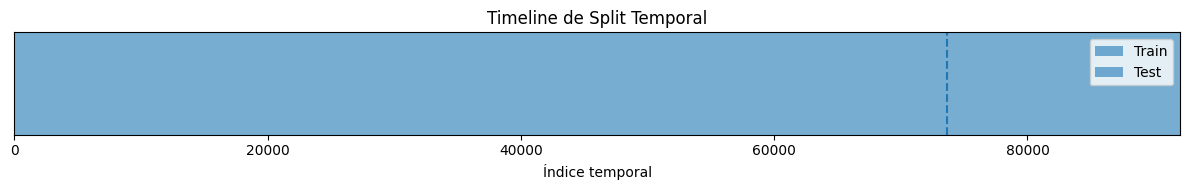

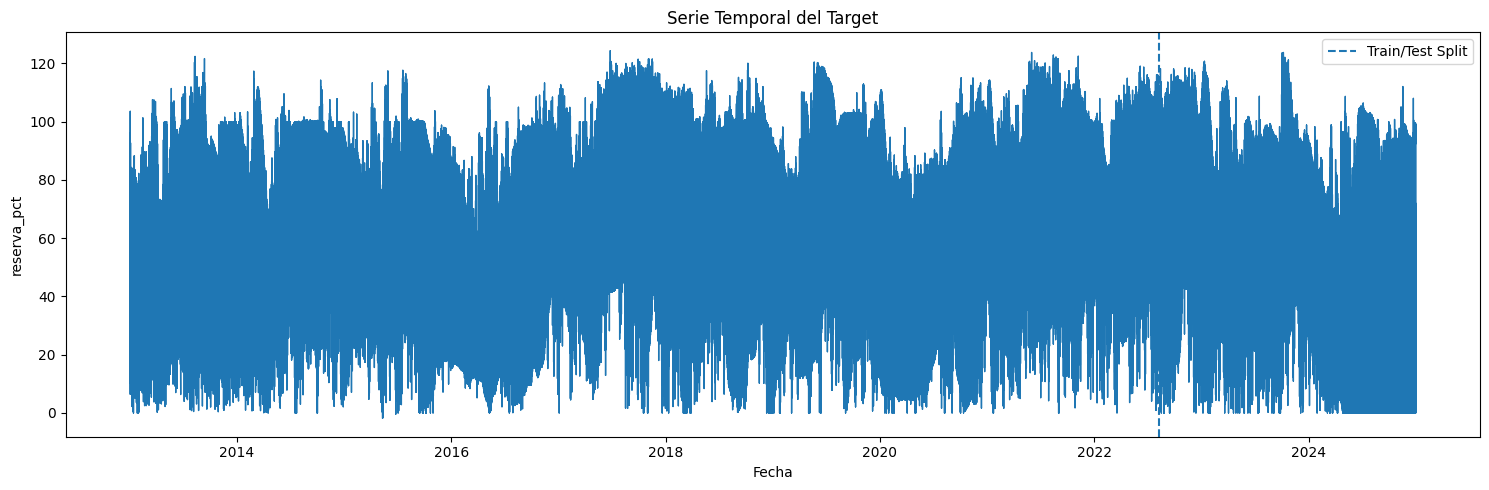

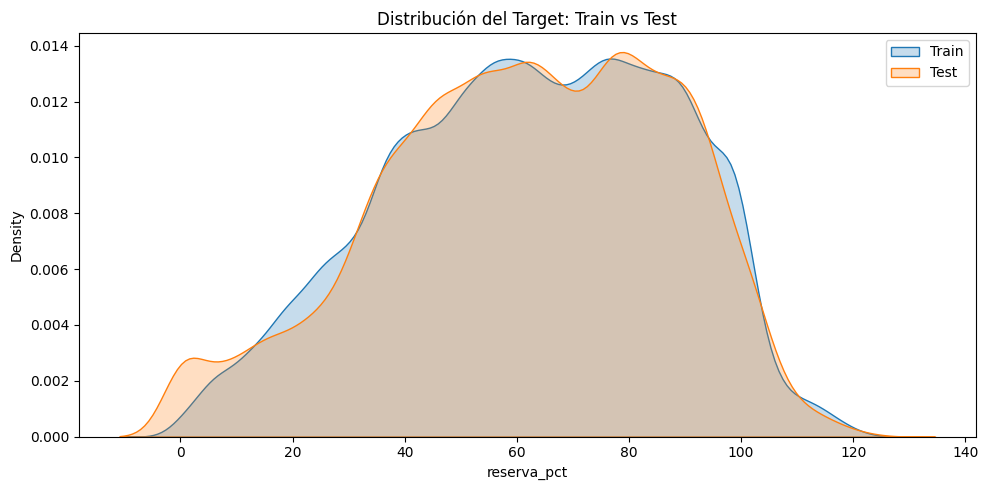

In [50]:
# =========================================================
# CONFIG GENERAL
# =========================================================

plt.style.use("default")

# =========================================================
# 1. TIMELINE DEL SPLIT TEMPORAL
# =========================================================

fig, ax = plt.subplots(figsize=(12, 2))

ax.axvspan(0, split_idx, alpha=0.6, label="Train")
ax.axvspan(split_idx, len(embalses), alpha=0.6, label="Test")

ax.axvline(split_idx, linestyle="--")

ax.set_xlim(0, len(embalses))
ax.set_yticks([])

ax.set_title("Timeline de Split Temporal")
ax.set_xlabel("Índice temporal")

ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 2. SERIE TEMPORAL DEL TARGET + SPLIT
# =========================================================

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    embalses["Fecha"],
    embalses[TARGET],
    linewidth=1
)

split_date = embalses.iloc[split_idx]["Fecha"]

ax.axvline(
    split_date,
    linestyle="--",
    label="Train/Test Split"
)

ax.set_title("Serie Temporal del Target")
ax.set_xlabel("Fecha")
ax.set_ylabel(TARGET)

ax.legend()

plt.tight_layout()
plt.show()

# =========================================================
# 3. DISTRIBUCIÓN TRAIN VS TEST
# =========================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    y_train,
    label="Train",
    fill=True,
    ax=ax
)

sns.kdeplot(
    y_test,
    label="Test",
    fill=True,
    ax=ax
)

ax.set_title("Distribución del Target: Train vs Test")
ax.set_xlabel(TARGET)

ax.legend()

plt.tight_layout()
plt.show()


### Análisis Comparación de Métricas


                                  RESULTADOS — MODELOS                                  


,rmse,mae,r2,experiment,MASE
4,6.233252,3.240701,0.941375,Naive Baseline,0.999946
0,21.395132,16.577761,0.309271,Extra Trees,5.115361
1,21.396737,17.070077,0.309168,XGBoost,5.267181
2,21.426400,17.044491,0.307251,Random Forest,5.259411
3,24.015454,18.726738,0.129720,Baseline Decision Tree,NaN


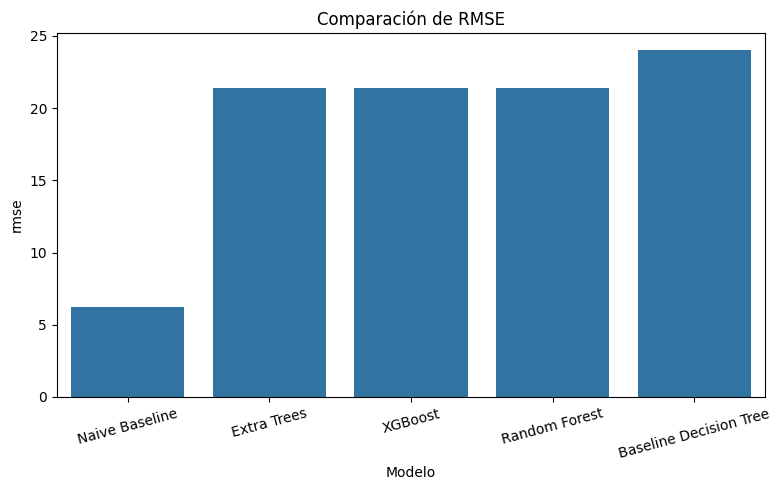

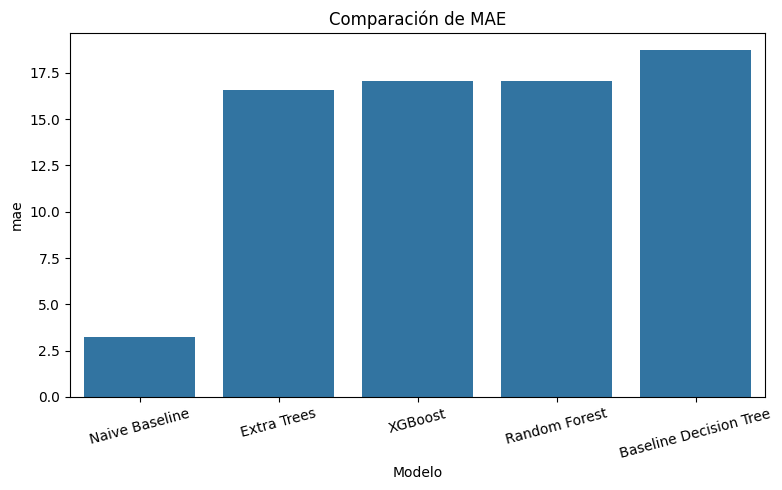

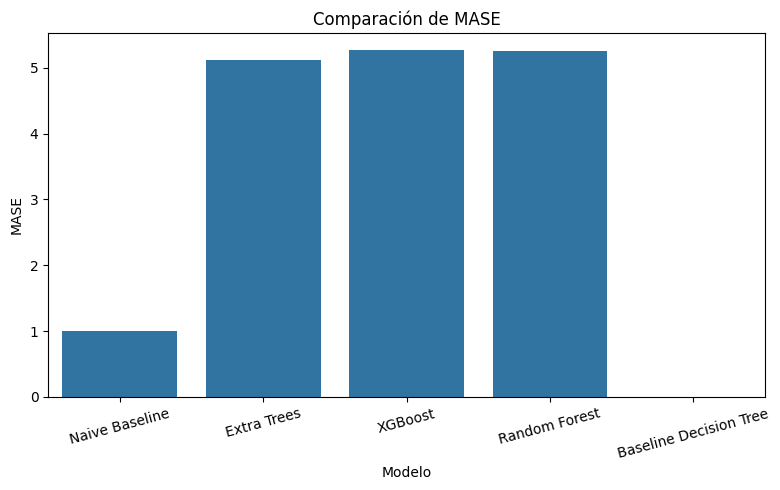

Embalses seleccionados:
['AGREGADO_BOGOTA', 'ALTOANCH', 'BETANIA', 'CALIMA1', 'CHUZA']
EMBALSE: AGREGADO_BOGOTA


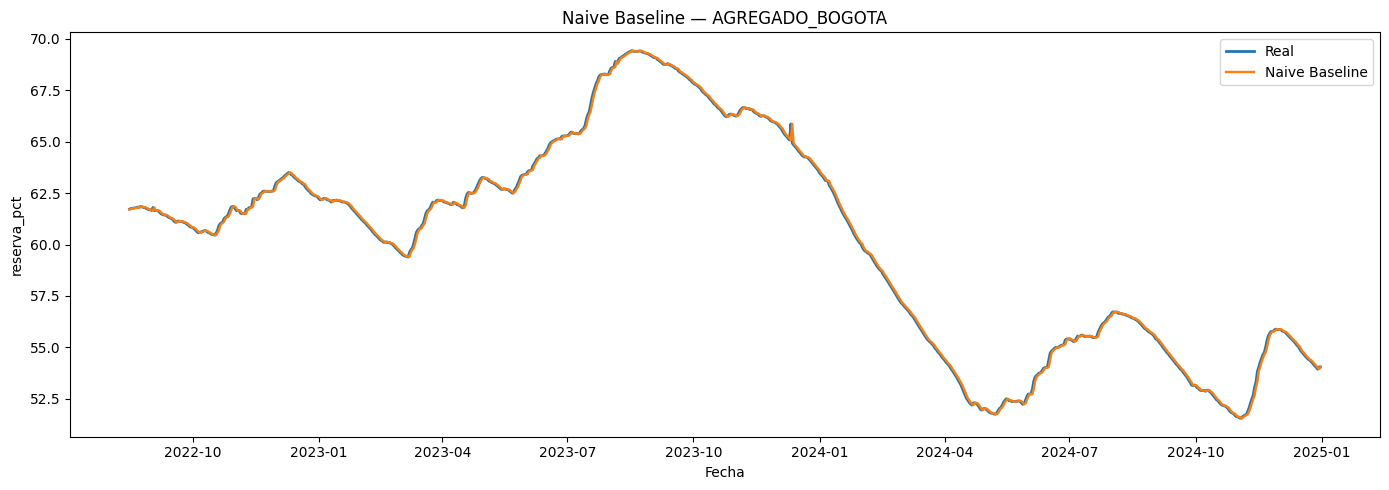

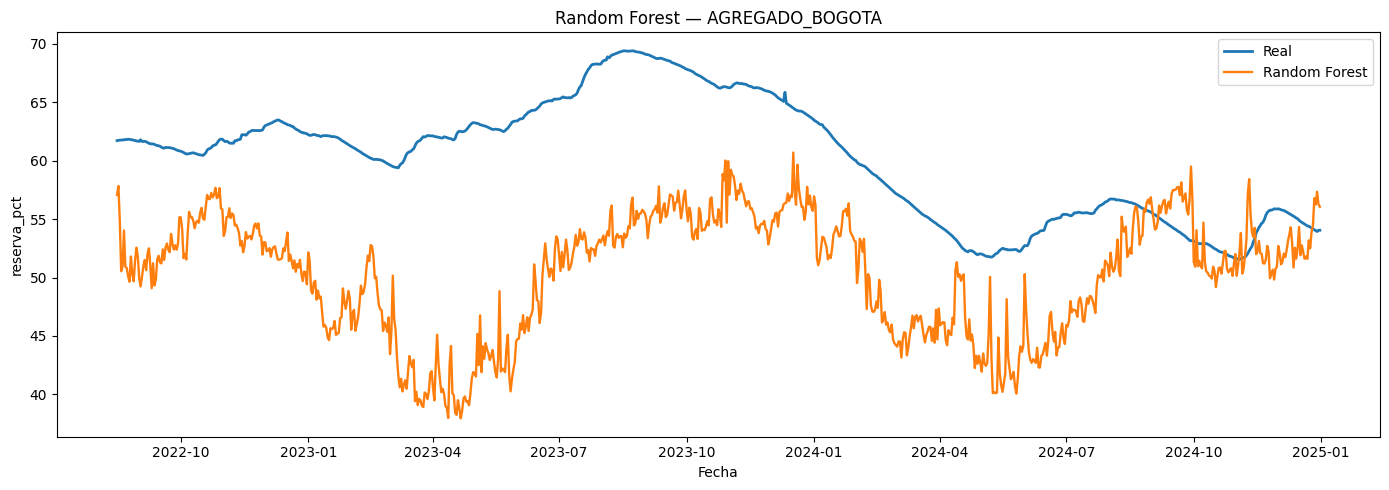

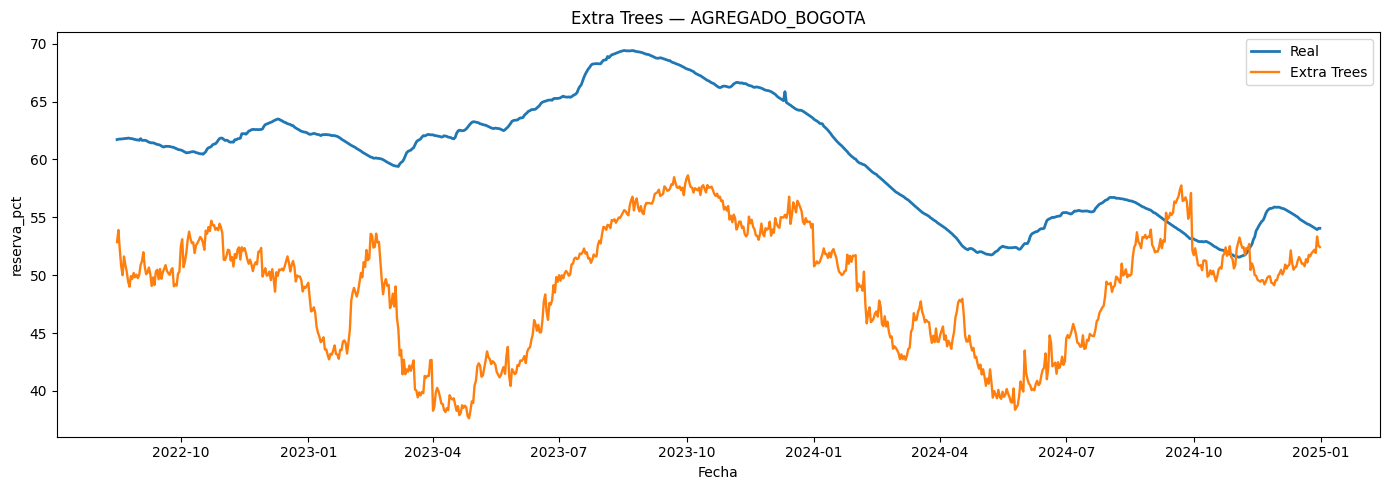

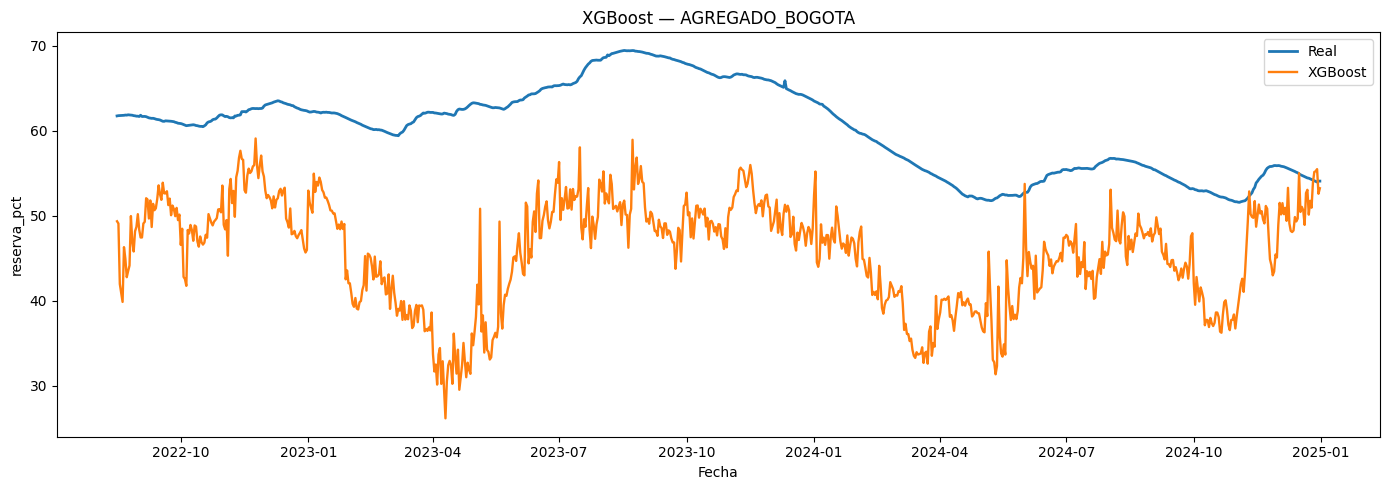

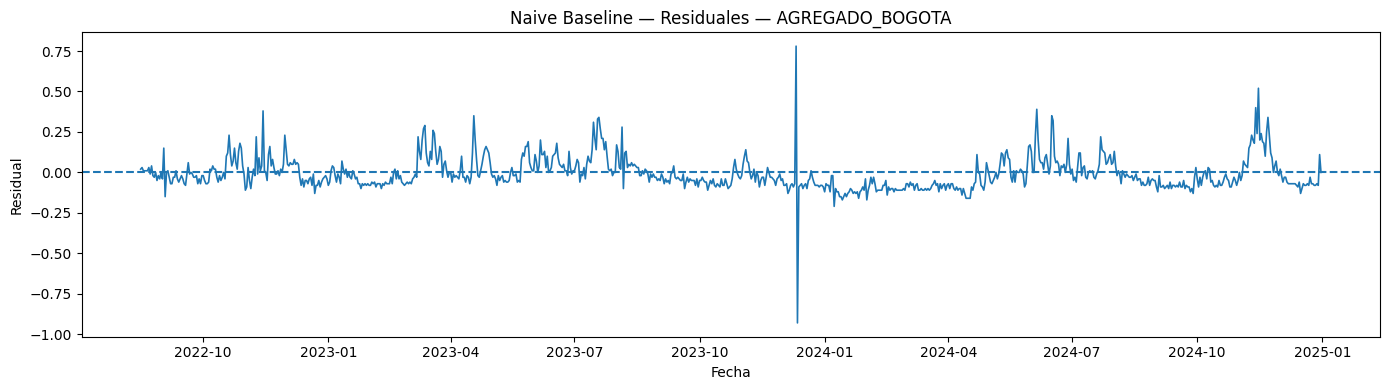

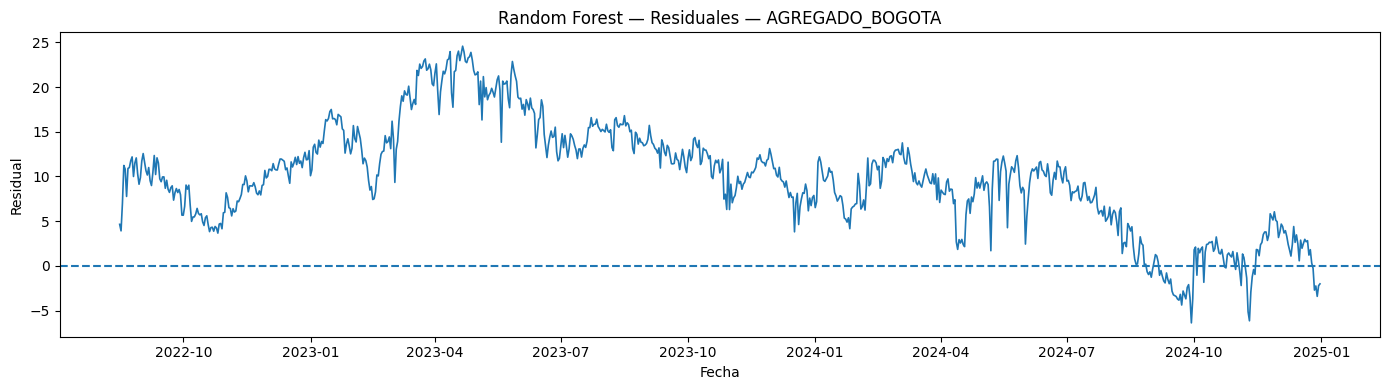

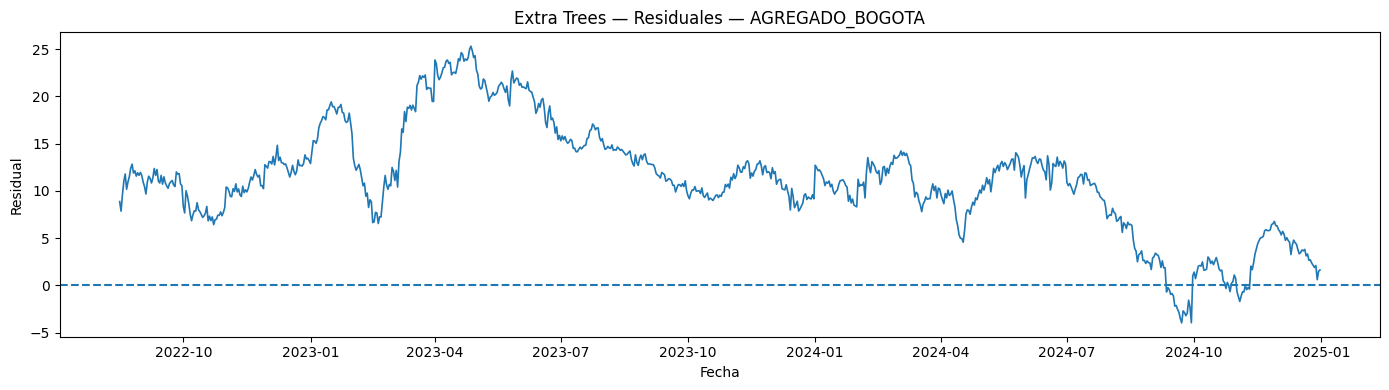

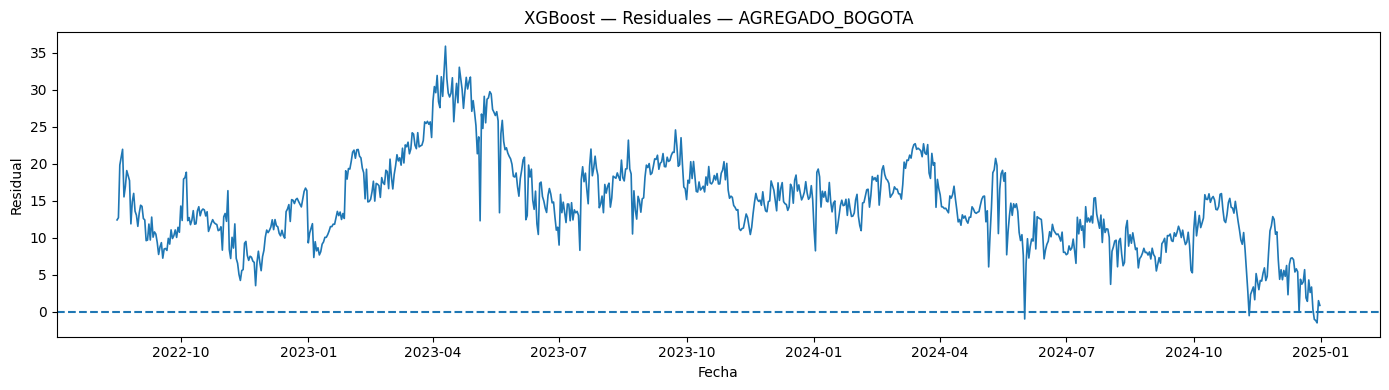

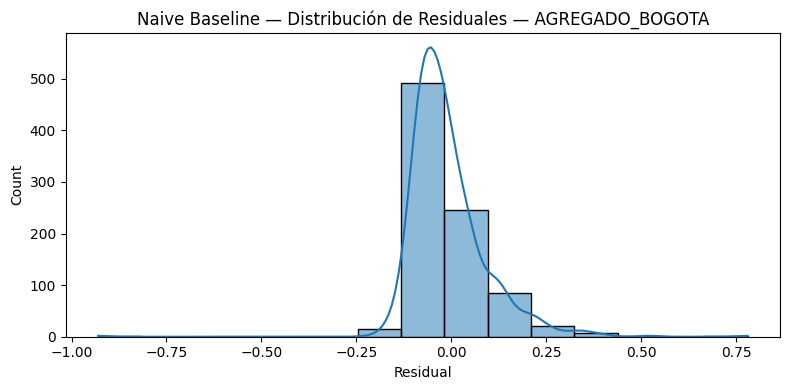

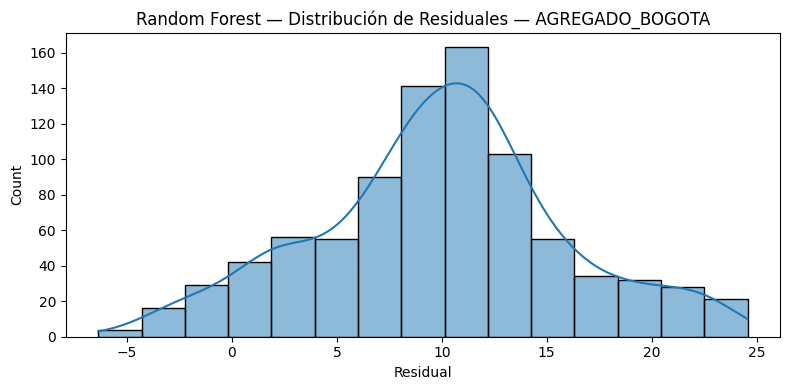

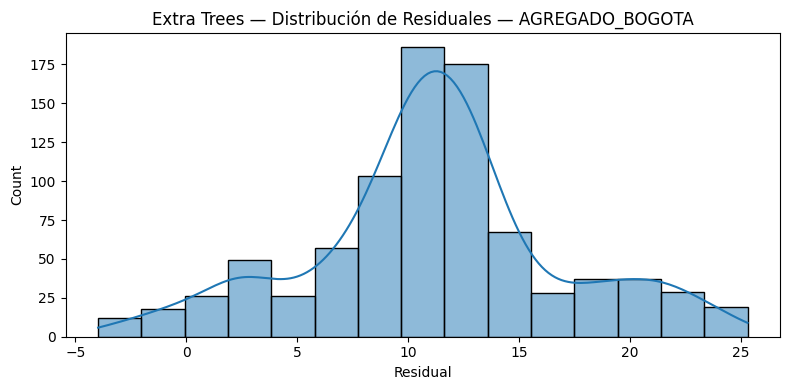

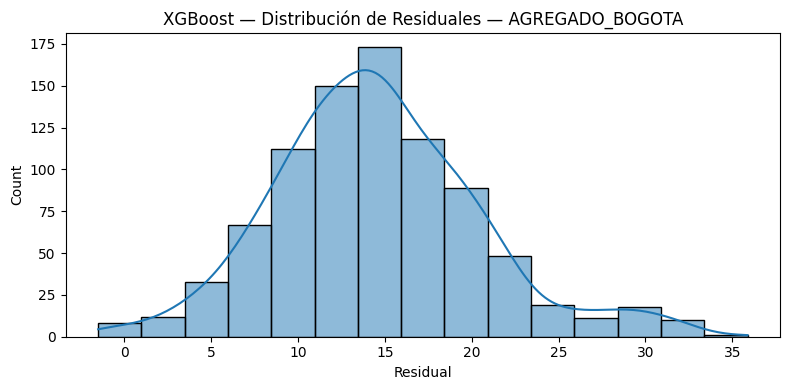

EMBALSE: ALTOANCH


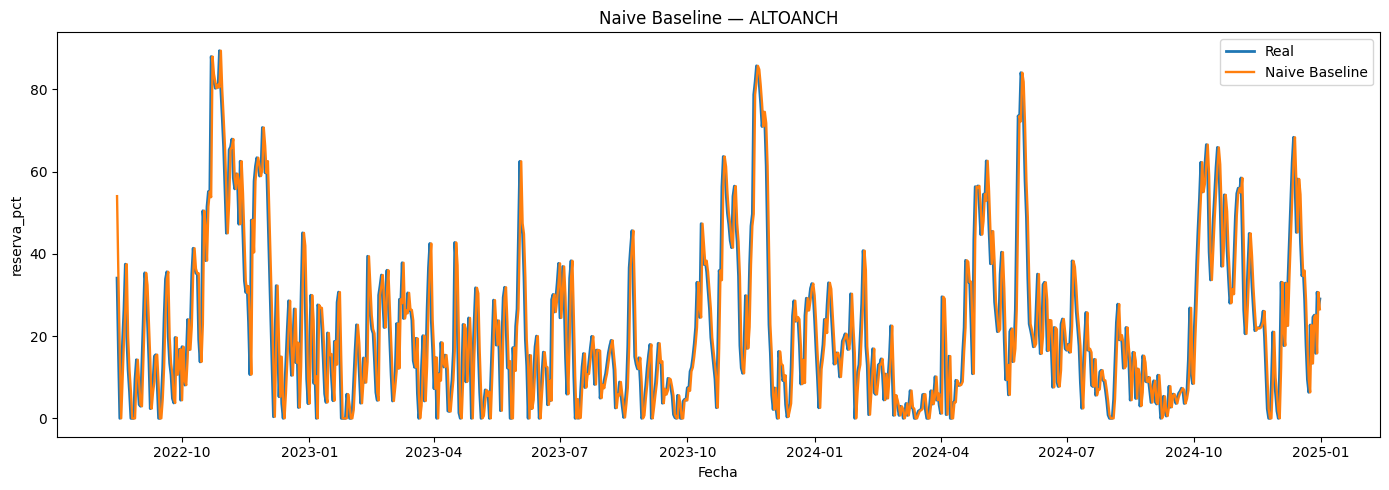

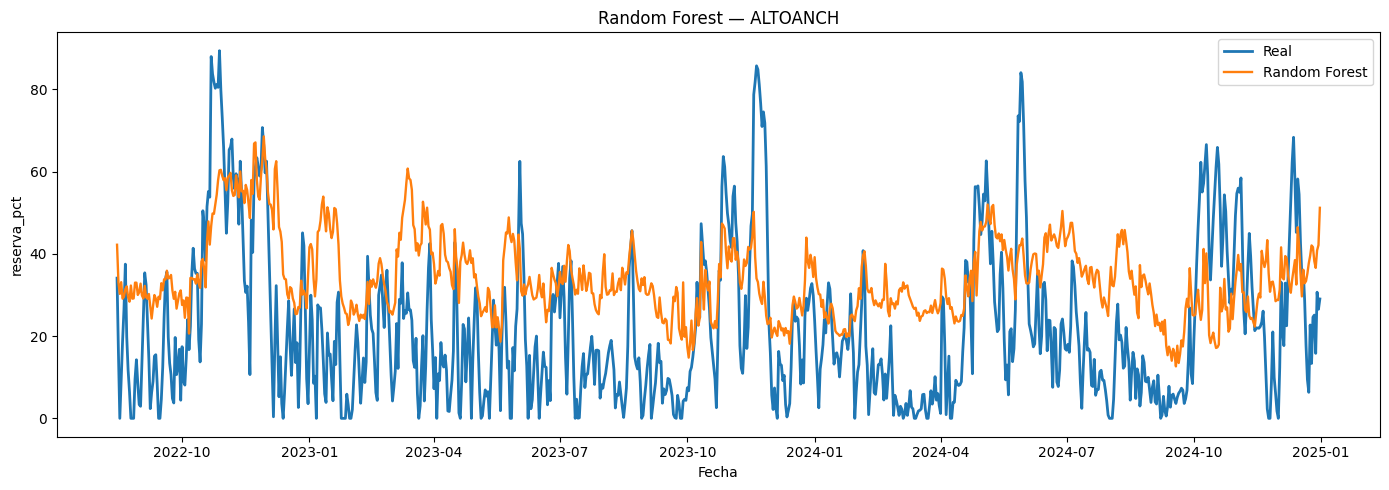

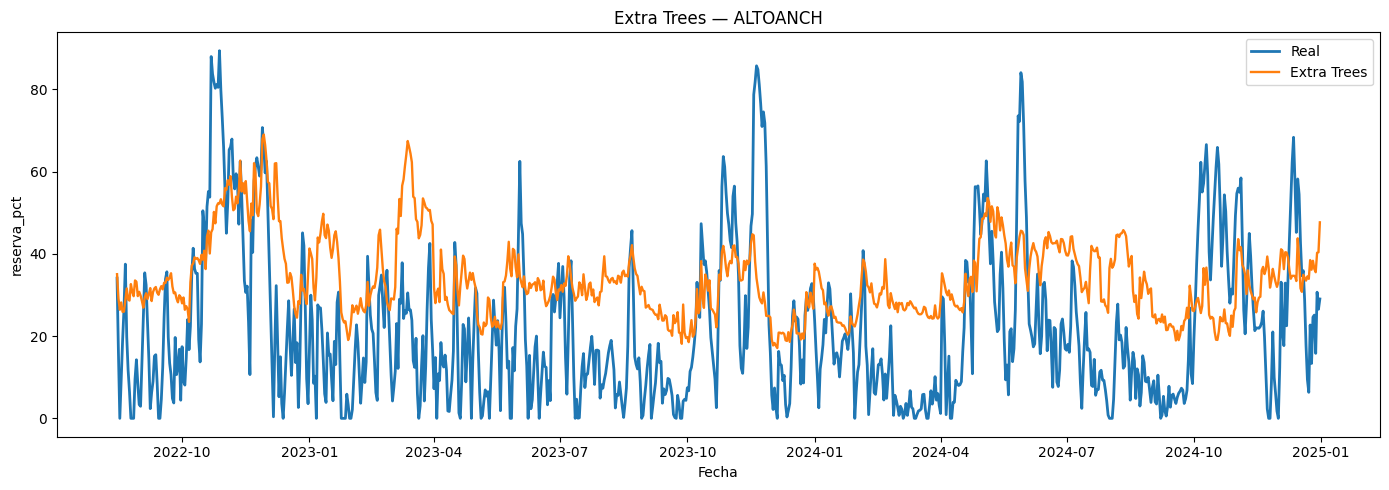

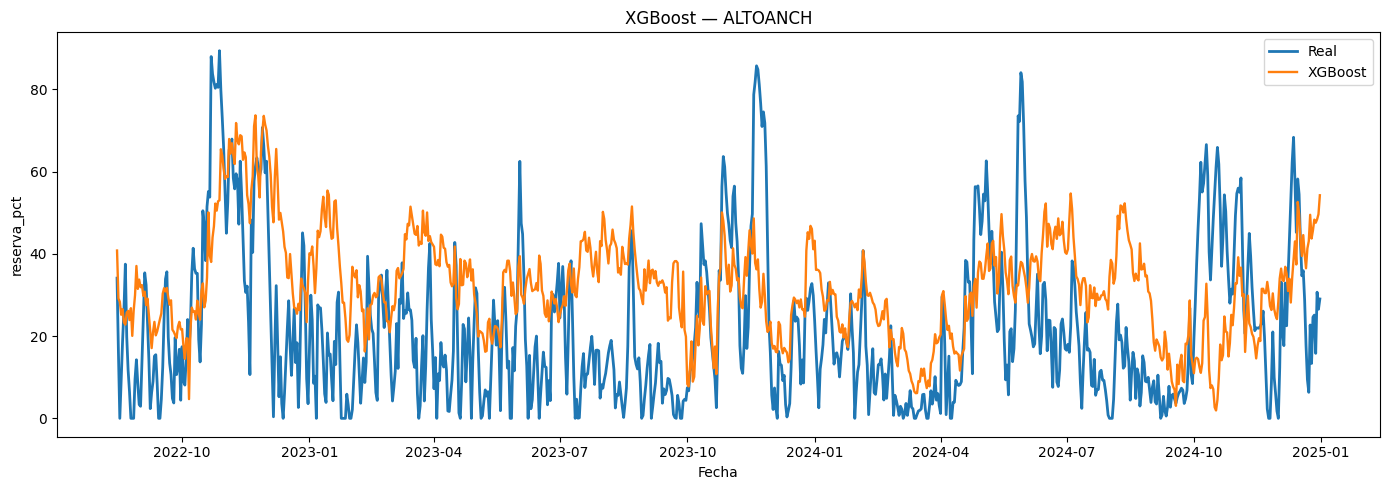

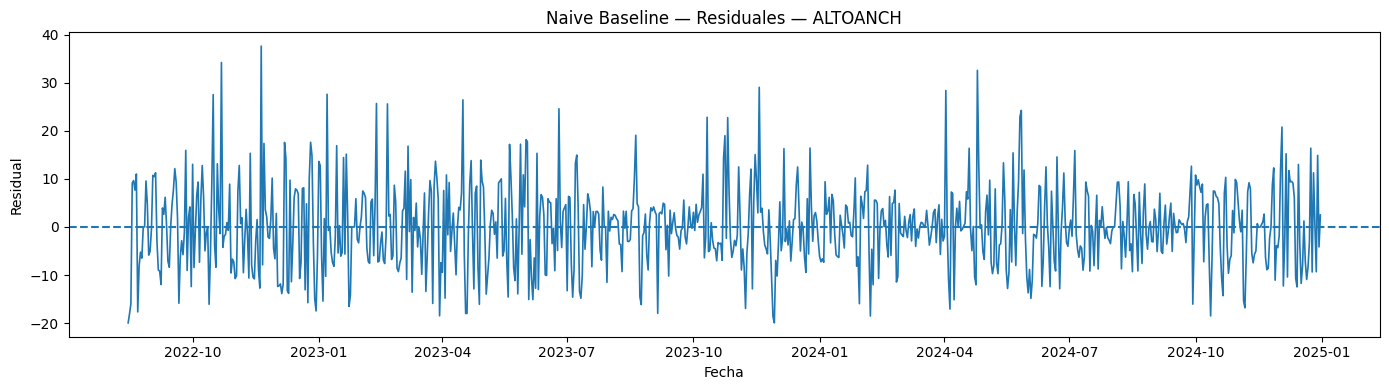

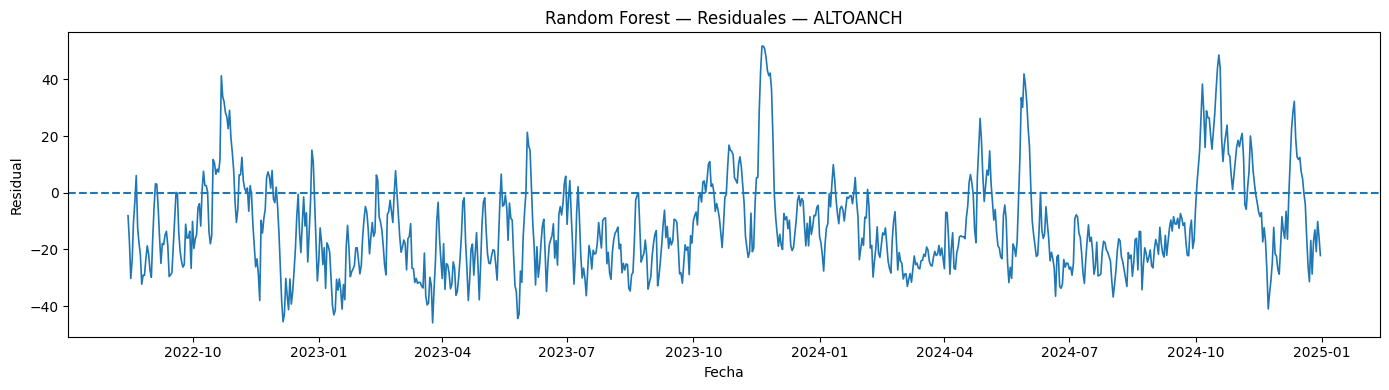

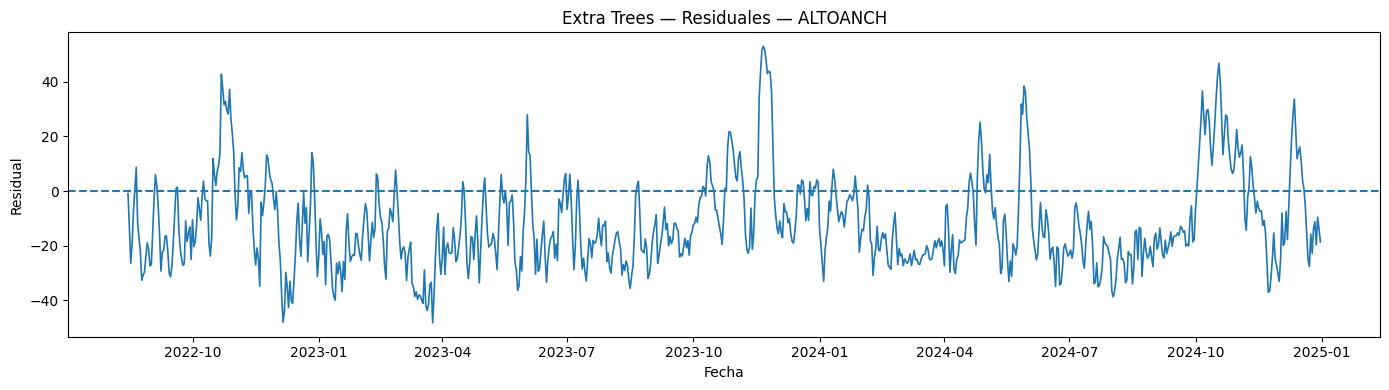

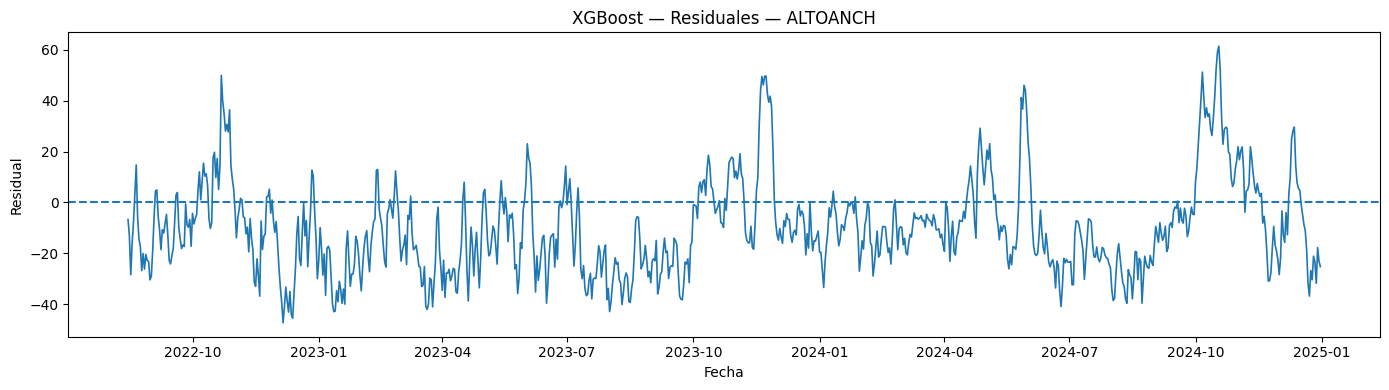

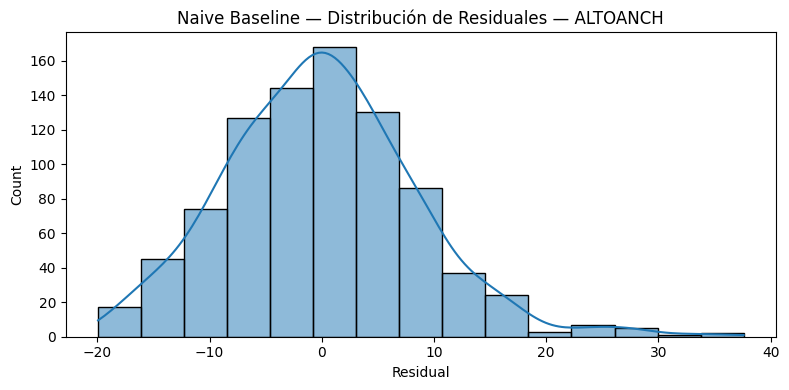

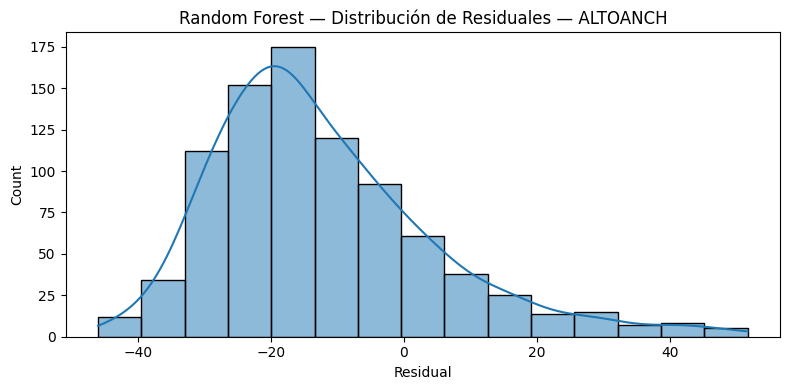

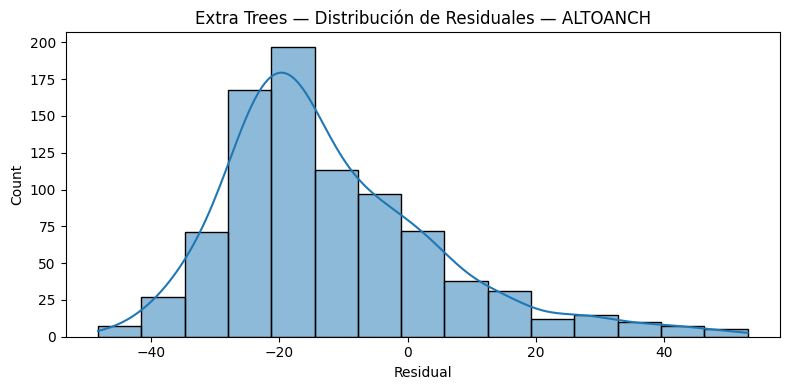

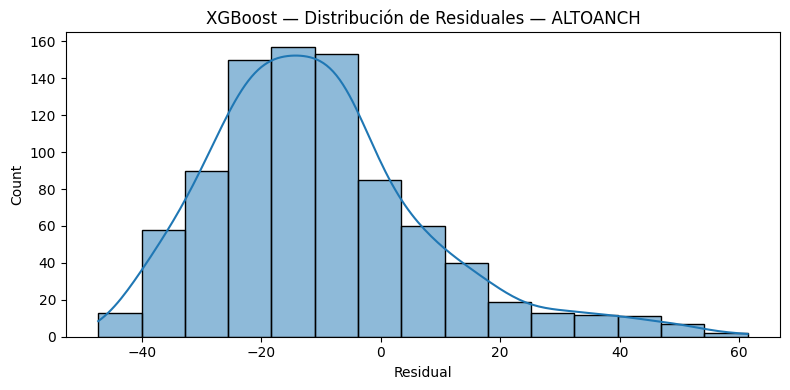

EMBALSE: BETANIA


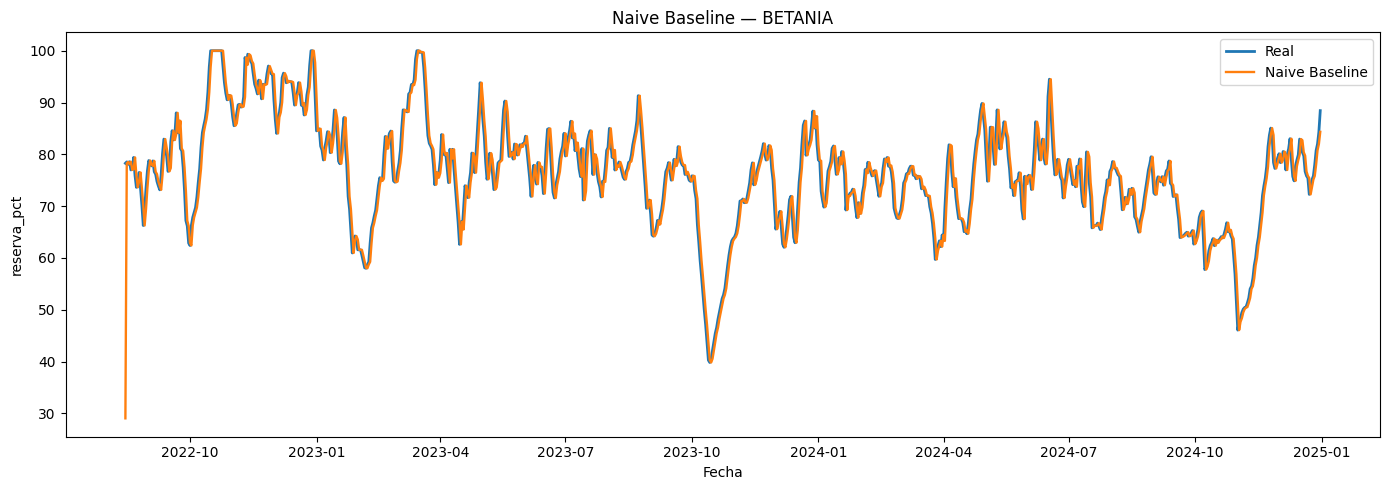

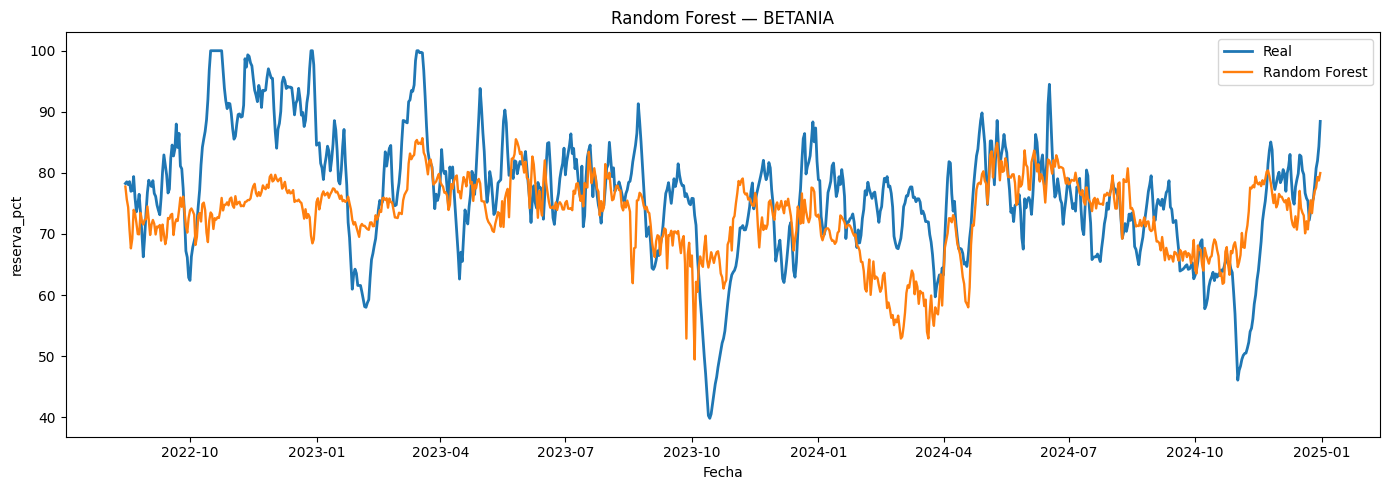

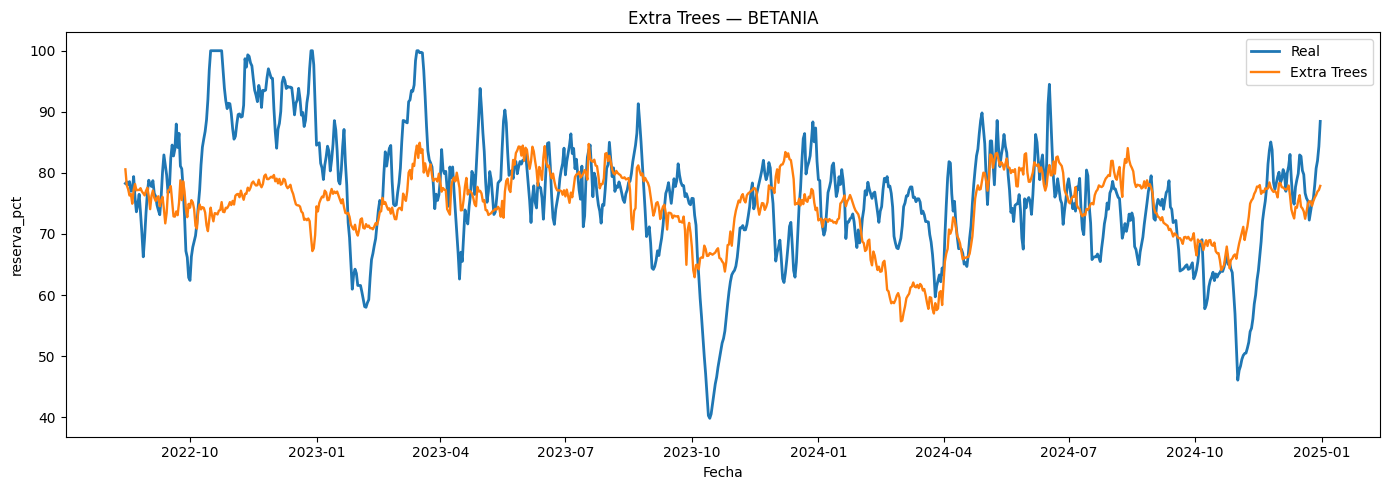

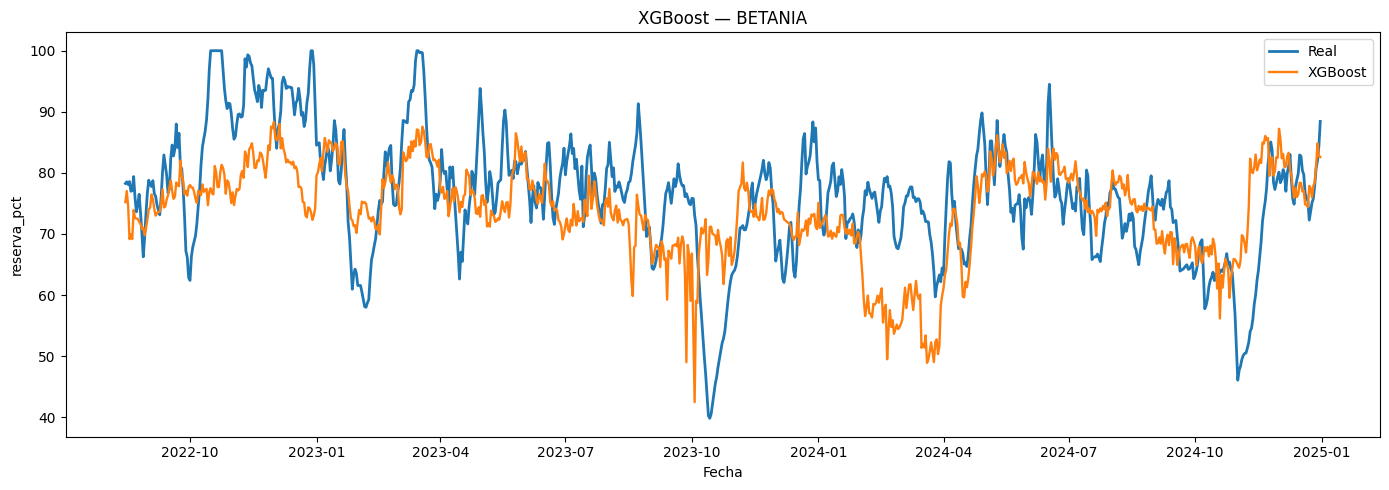

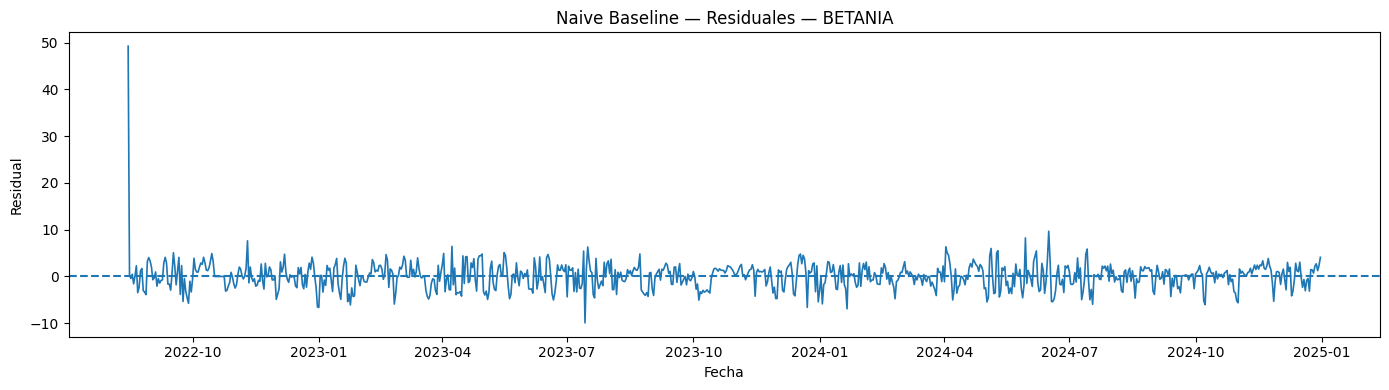

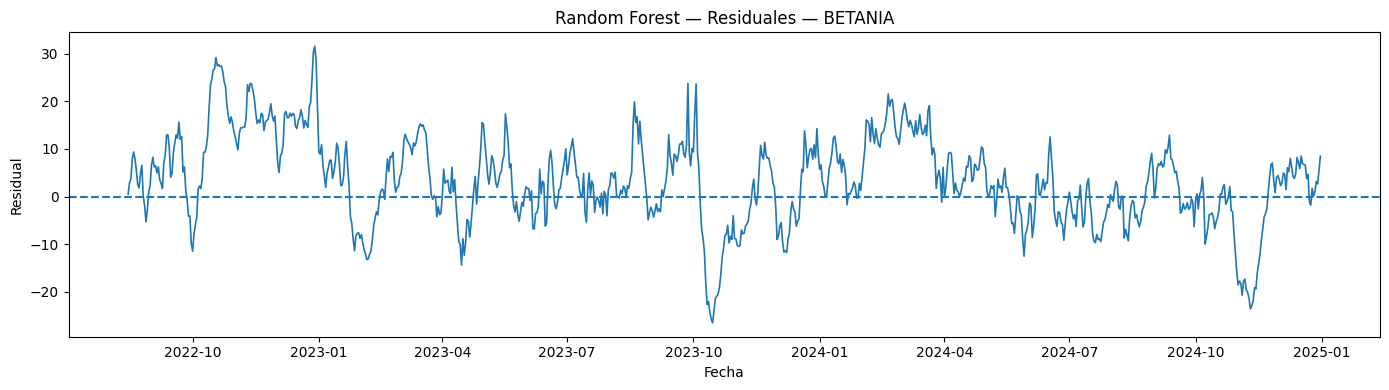

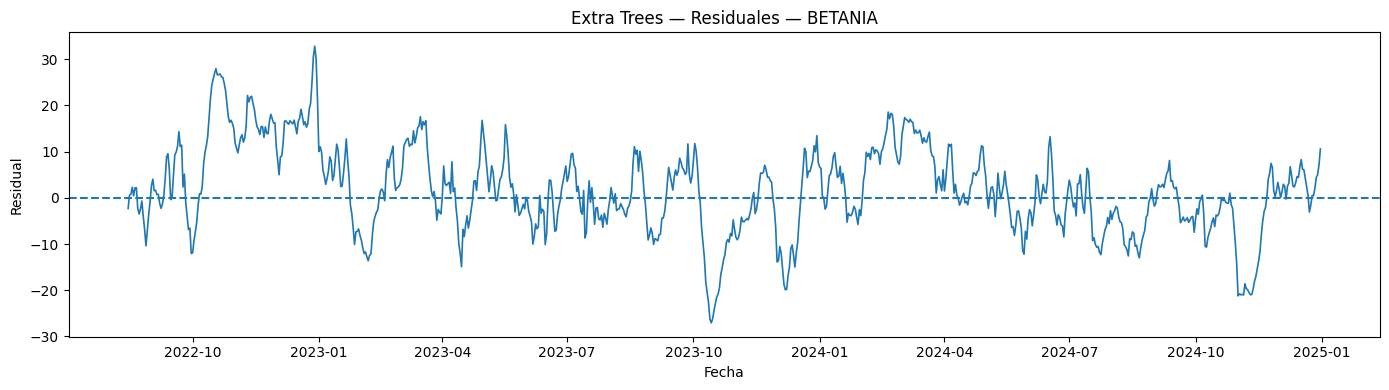

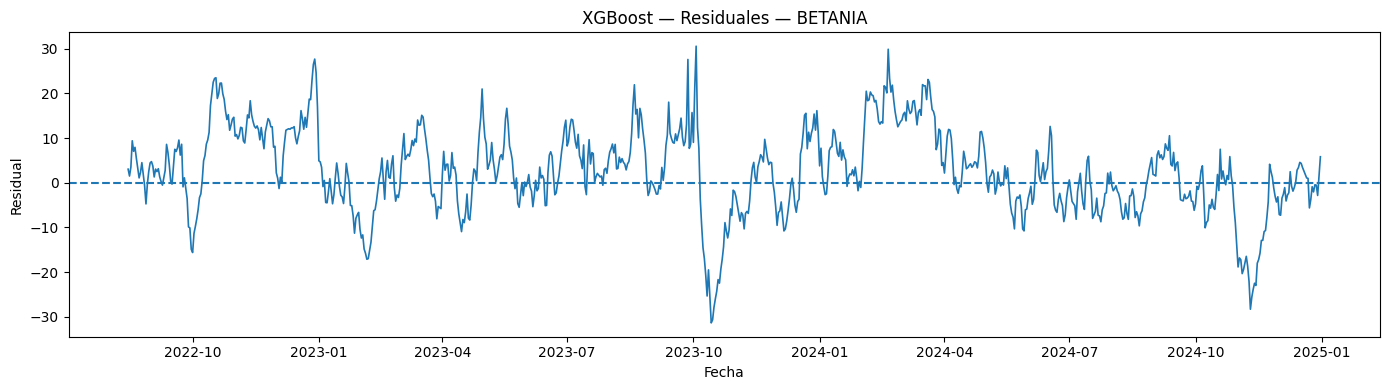

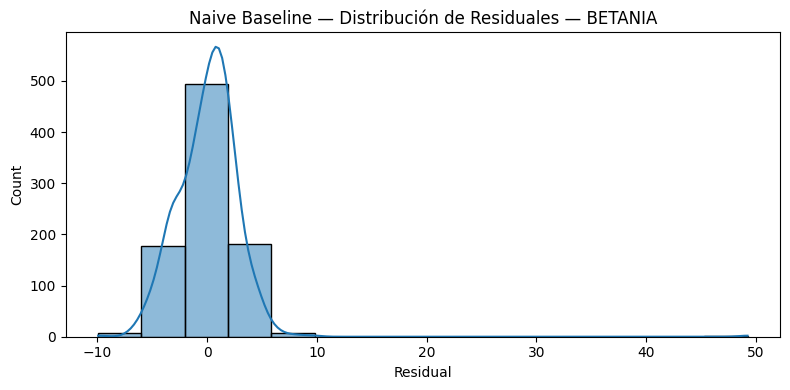

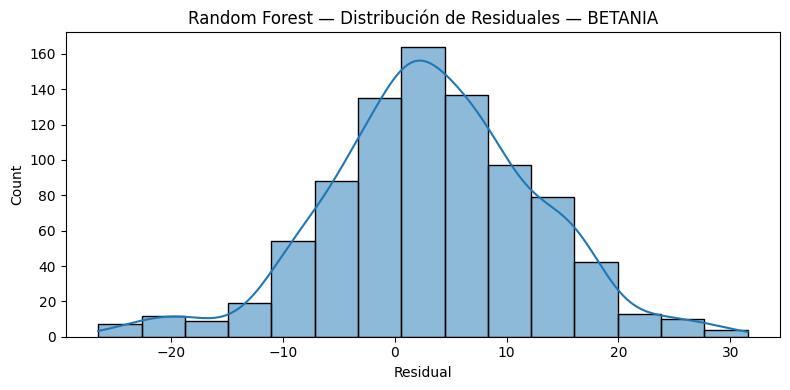

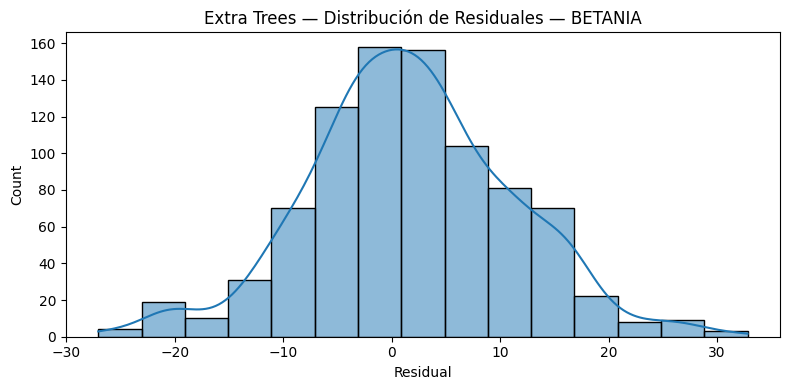

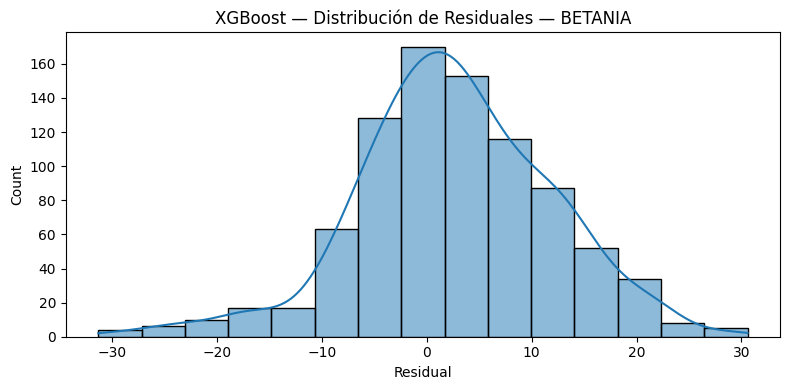

EMBALSE: CALIMA1


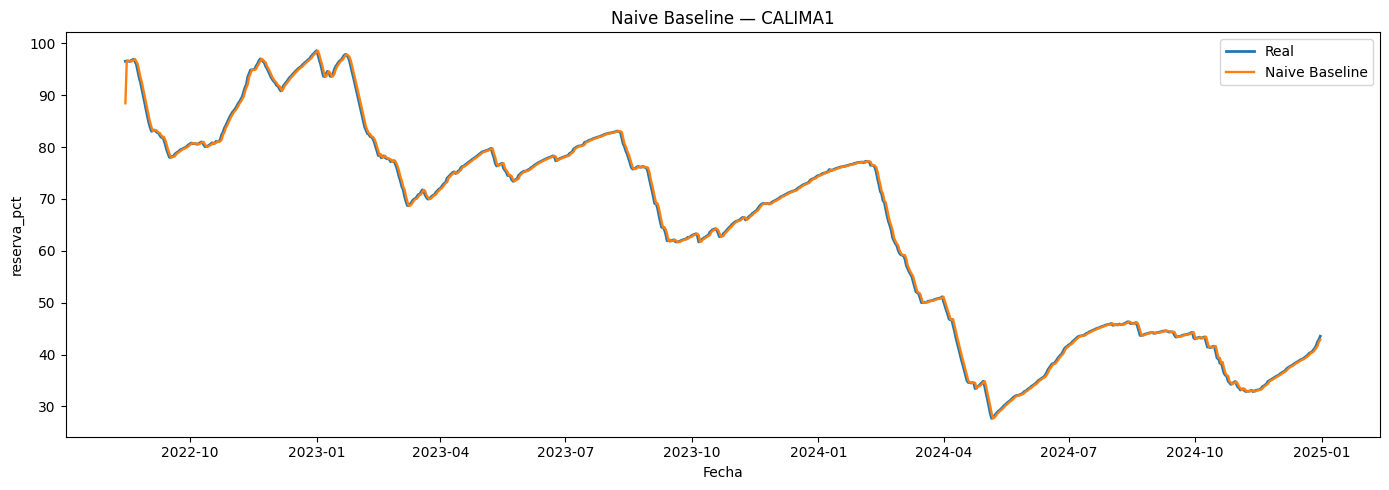

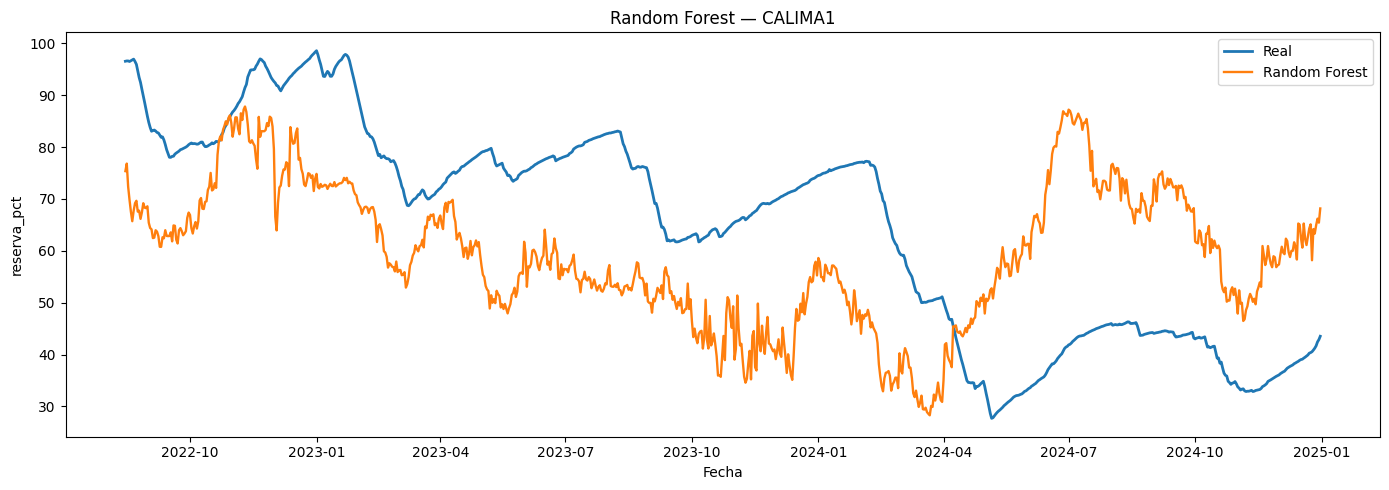

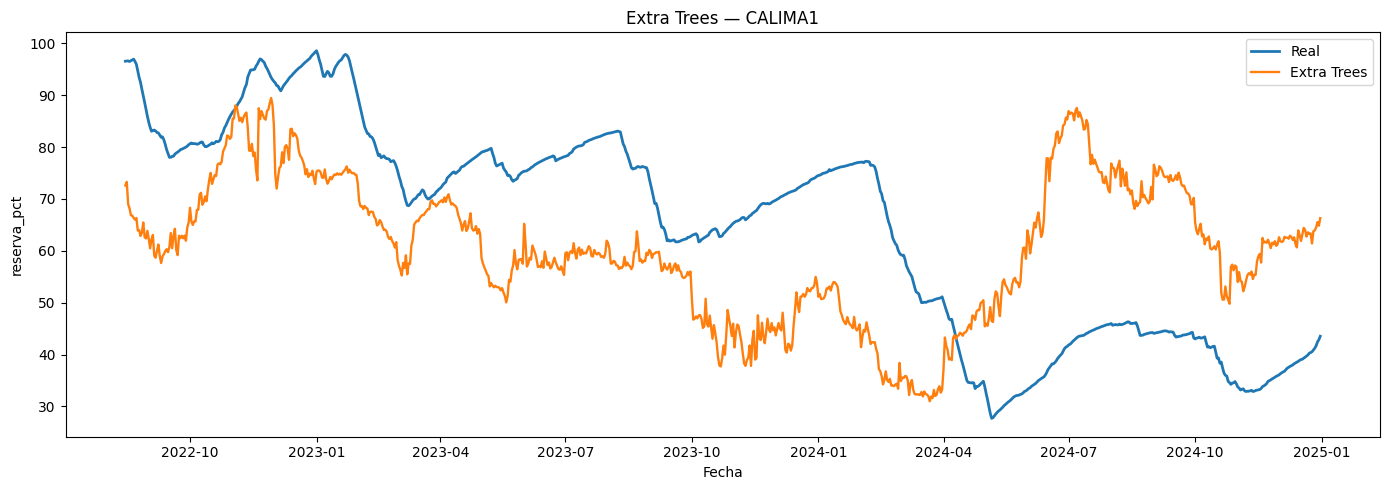

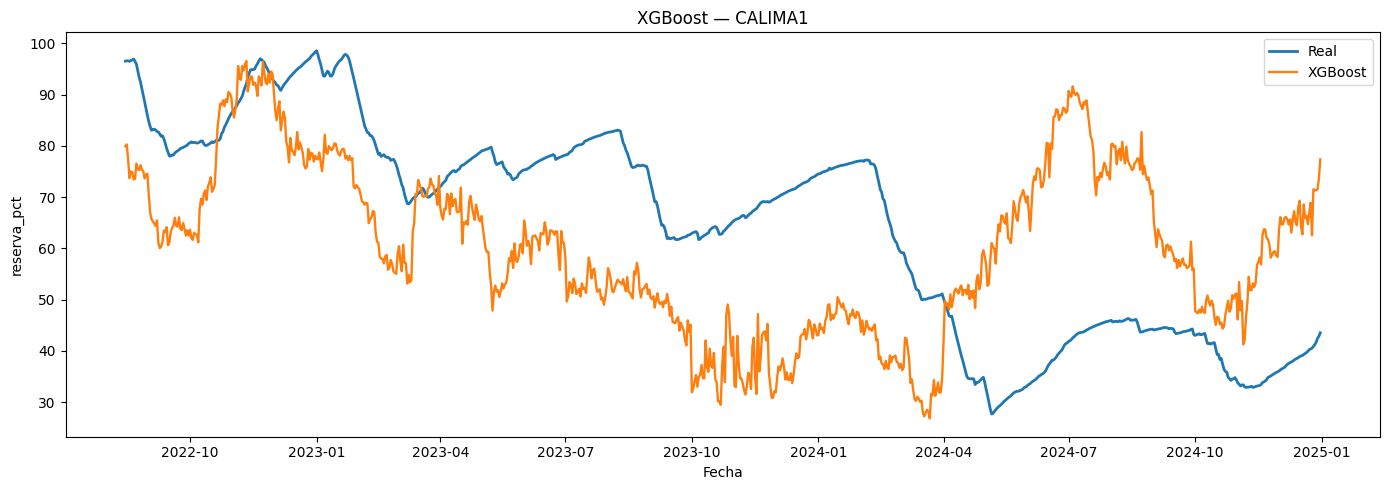

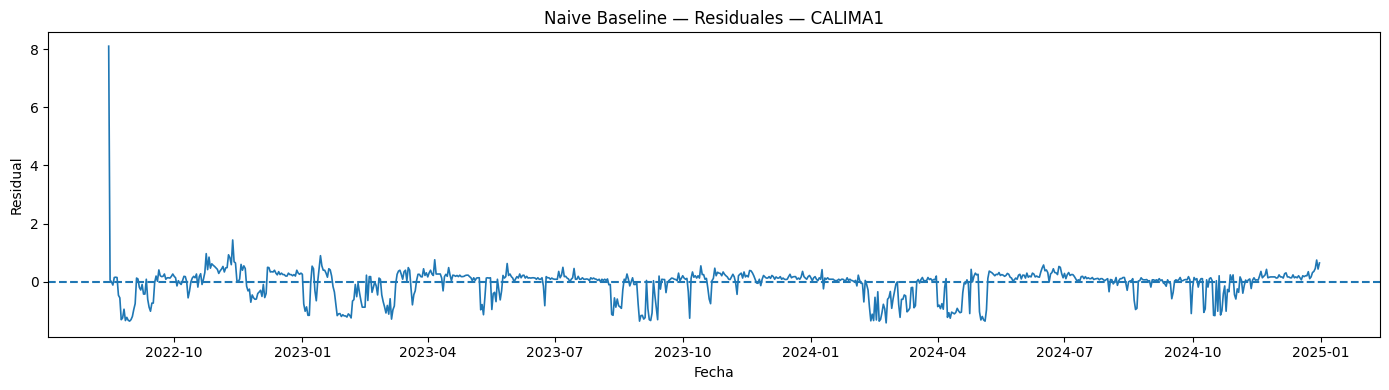

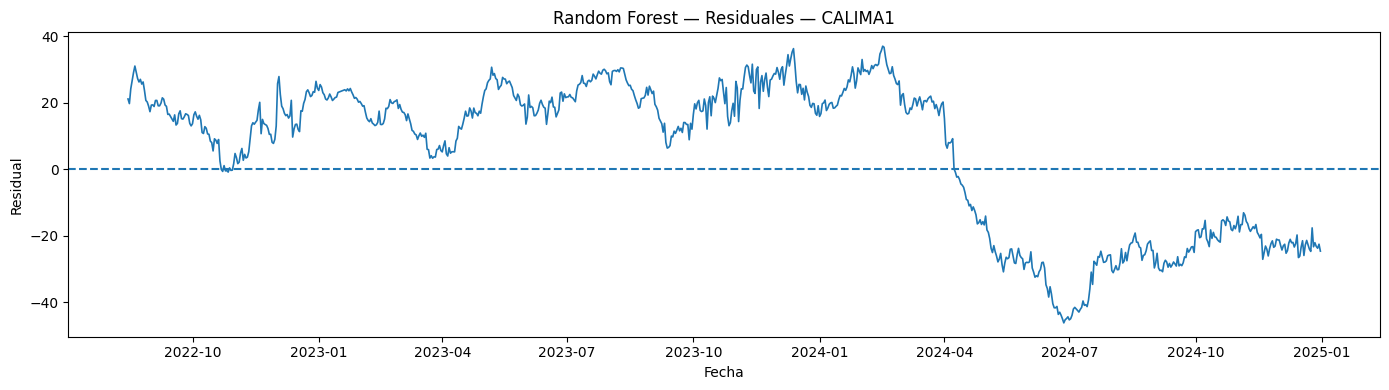

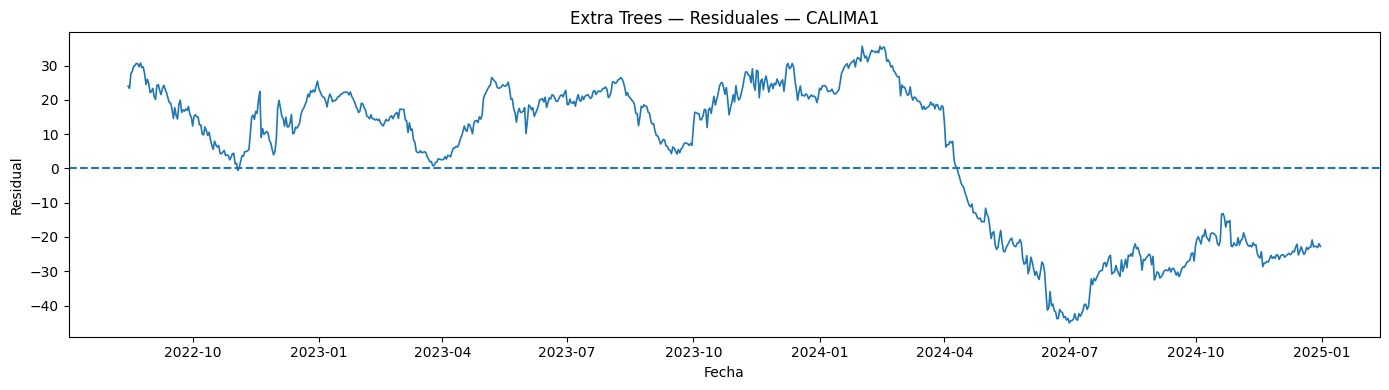

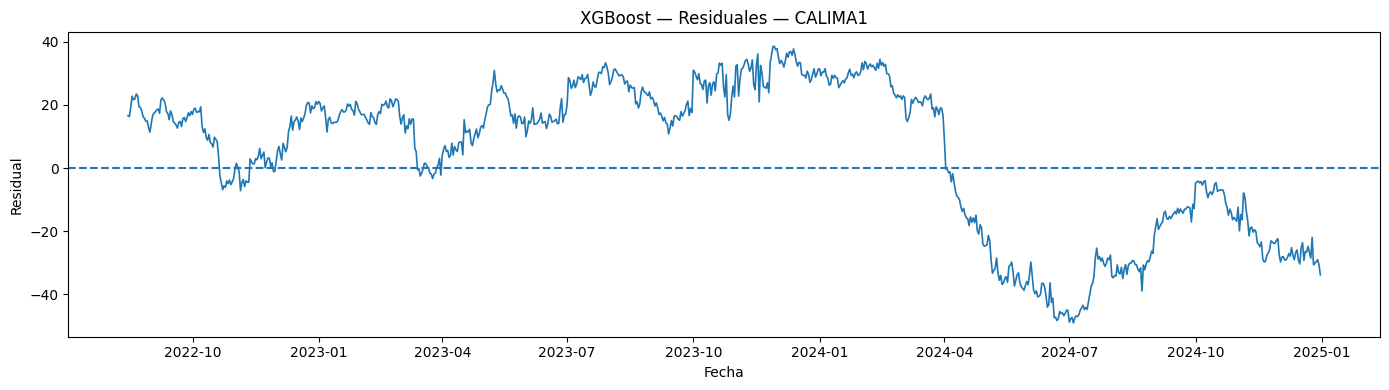

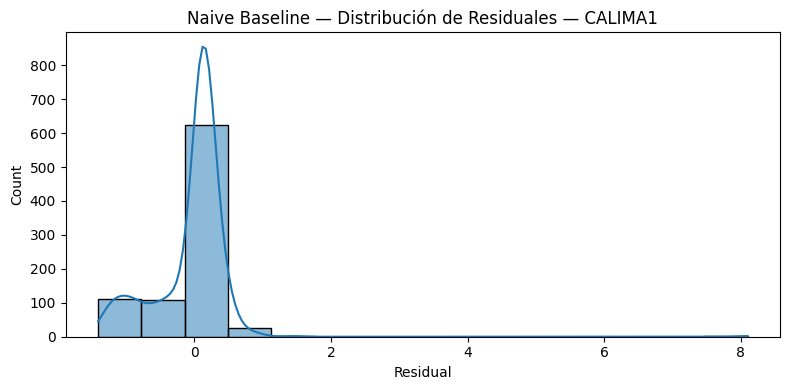

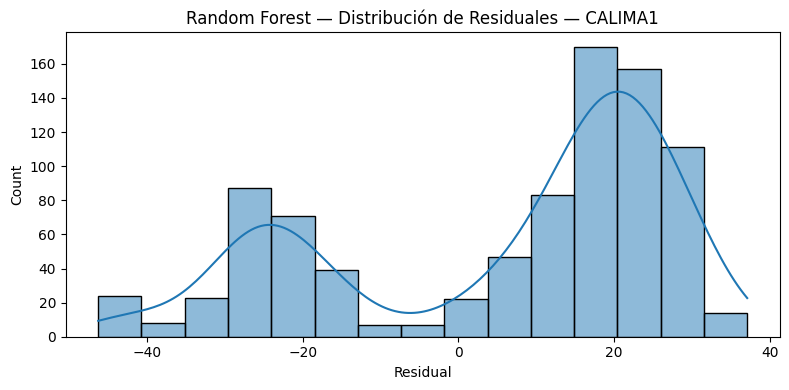

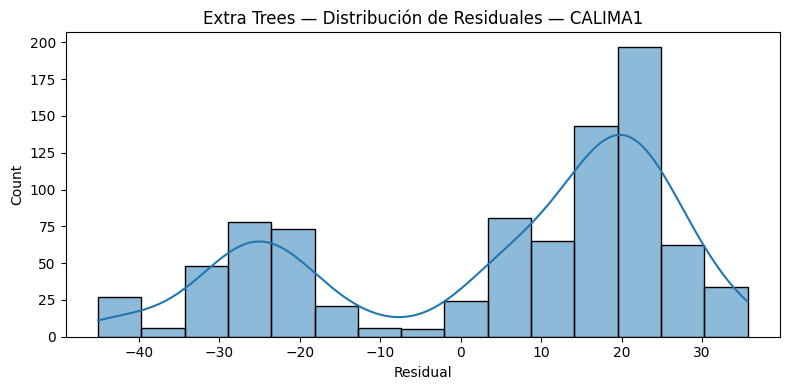

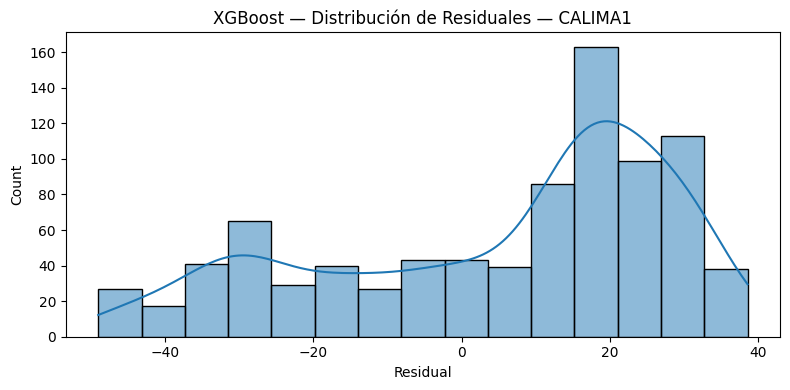

EMBALSE: CHUZA


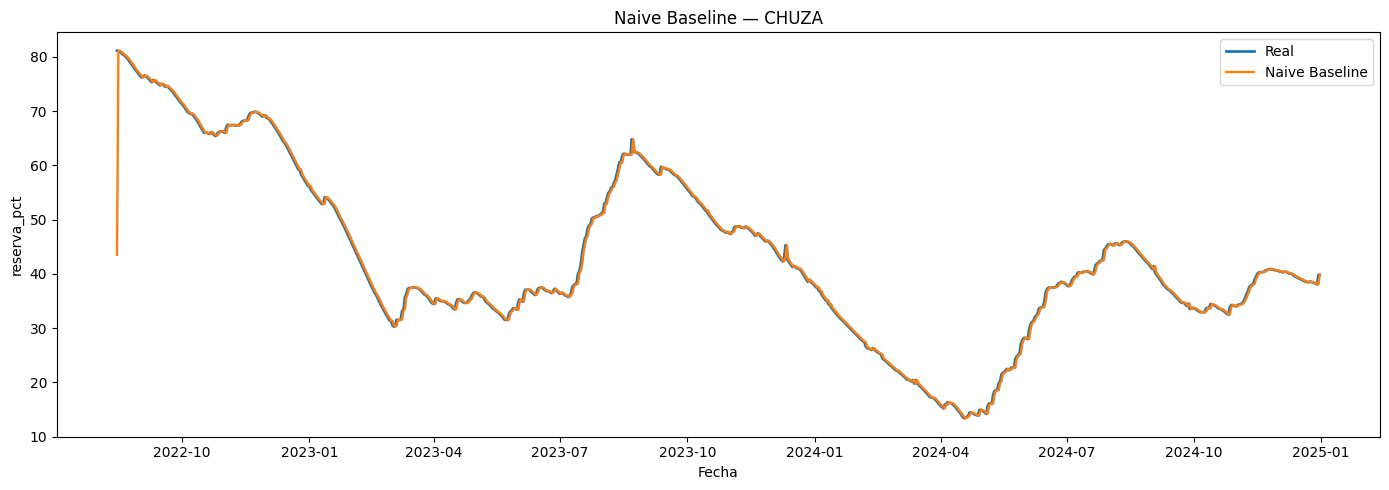

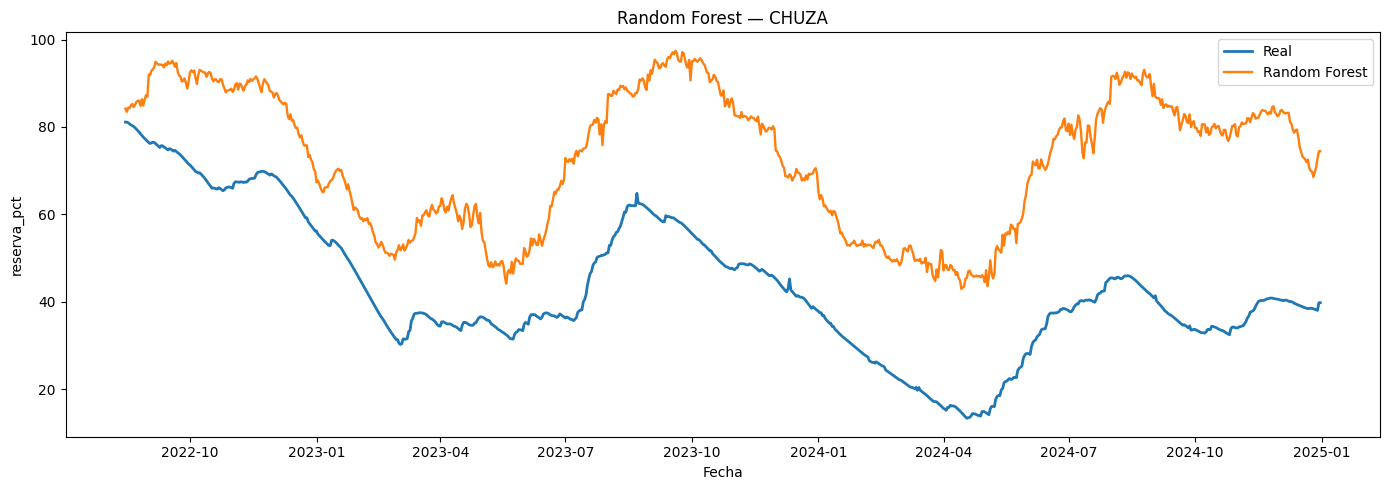

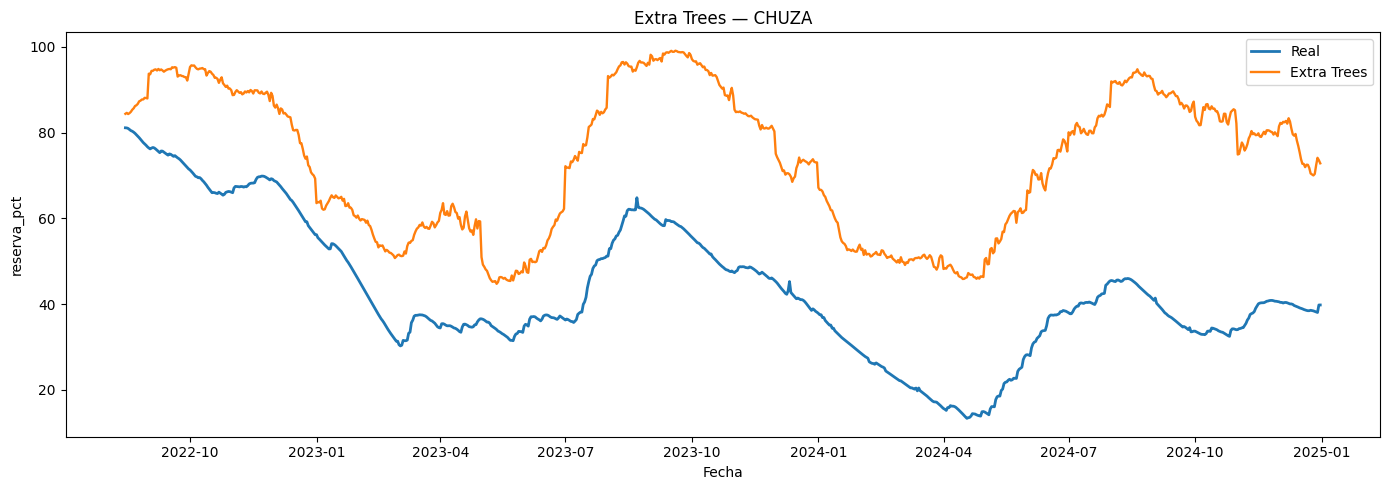

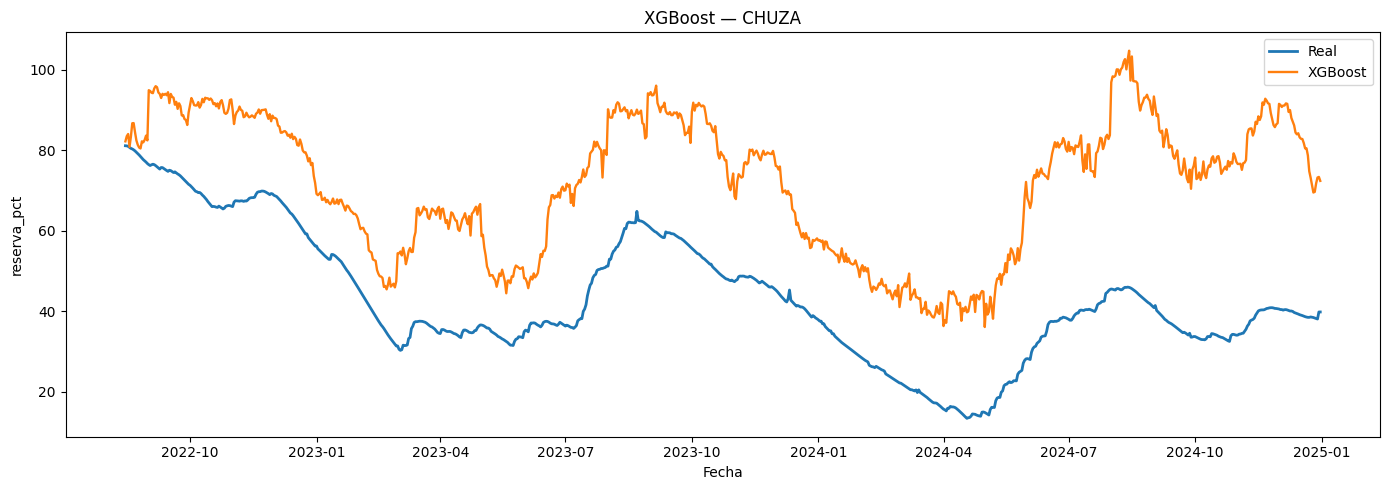

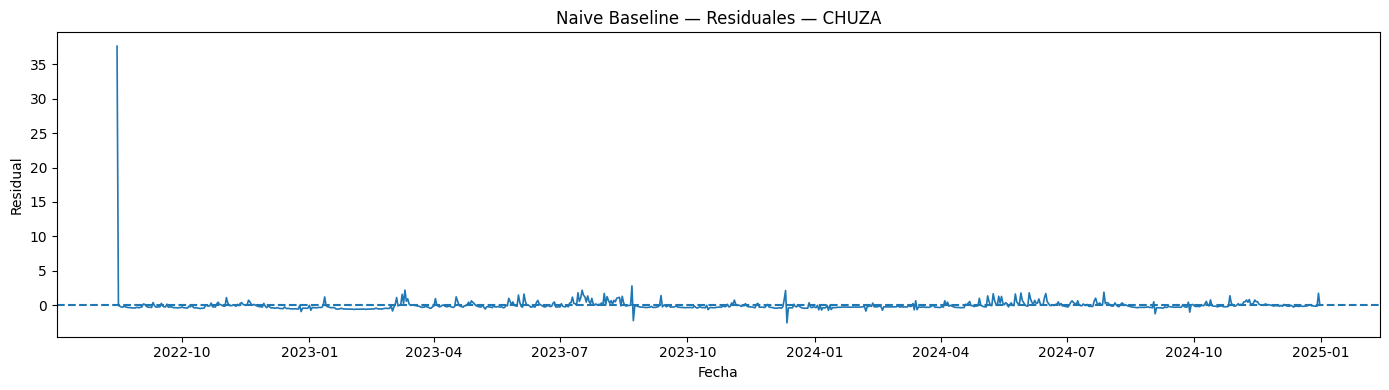

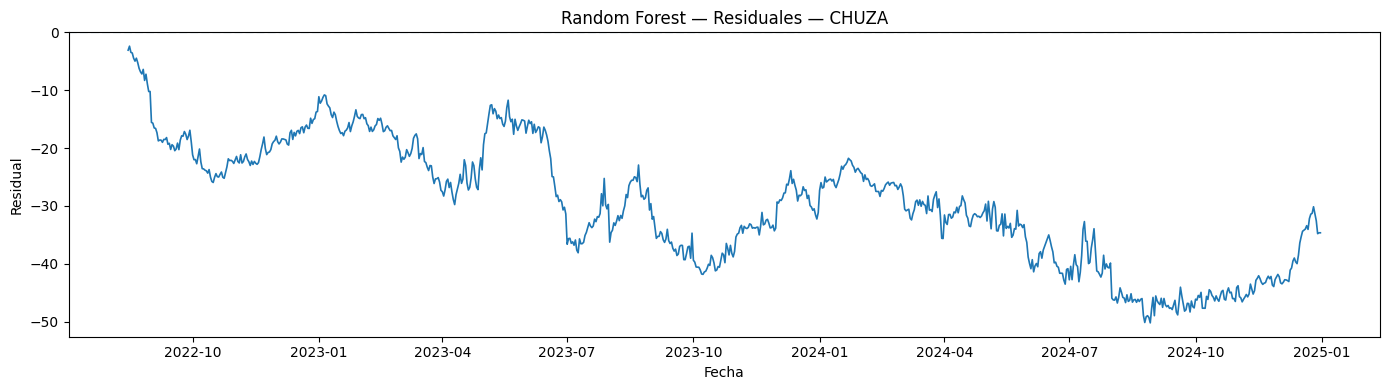

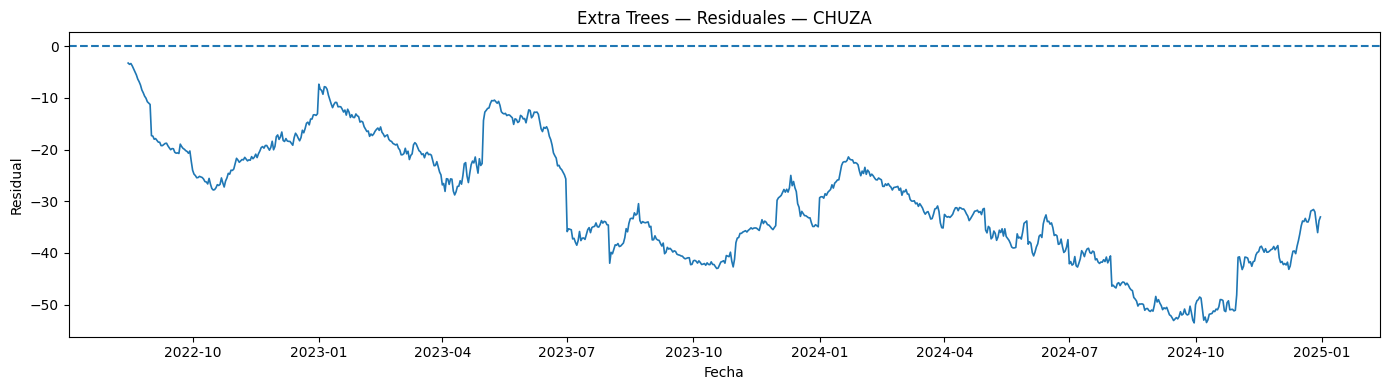

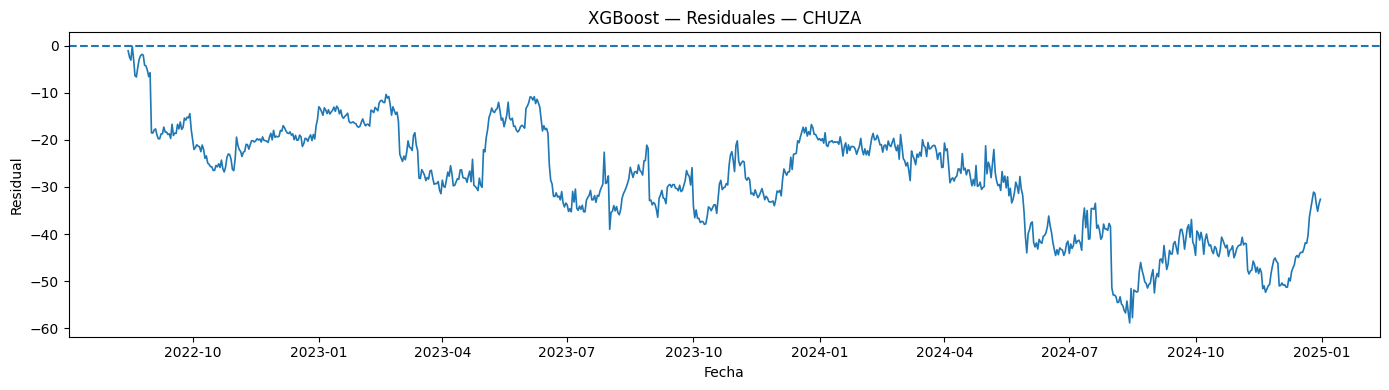

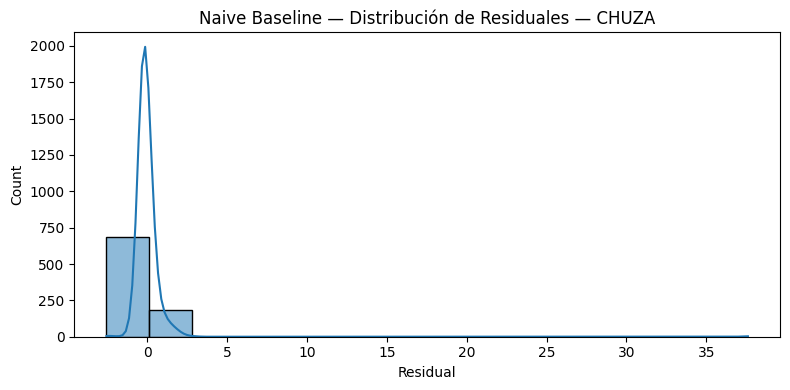

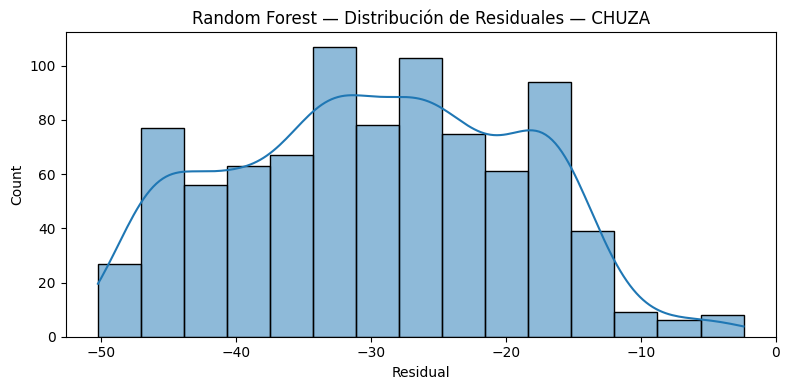

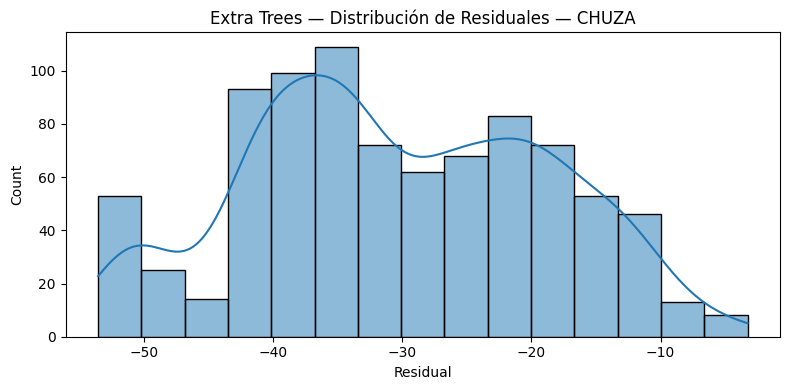

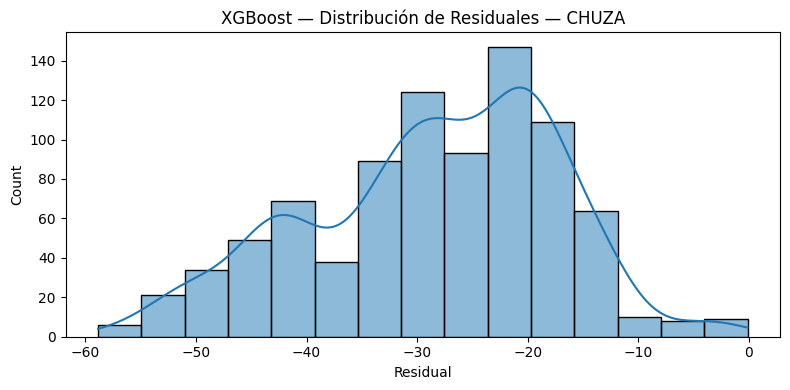

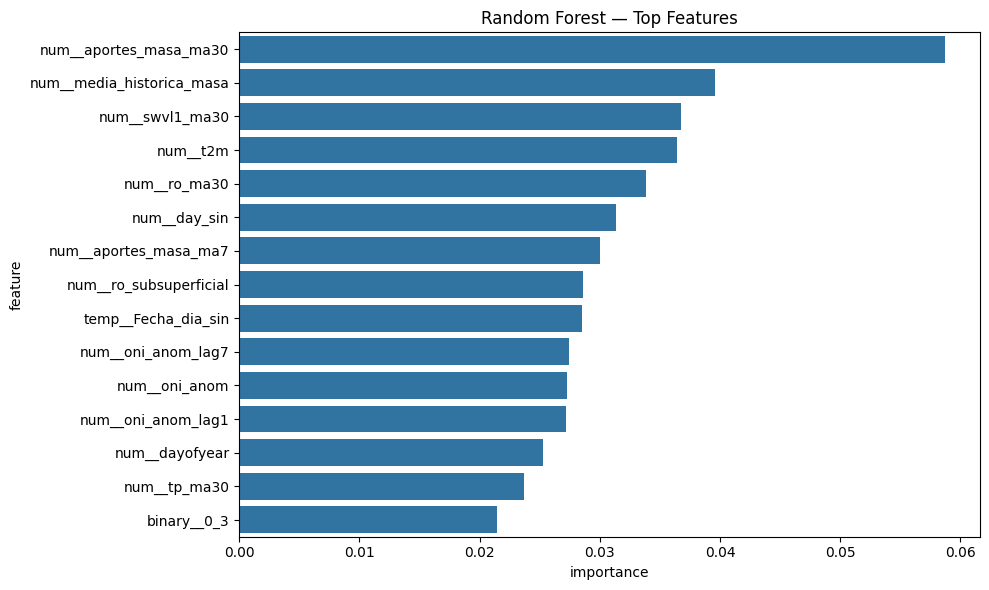

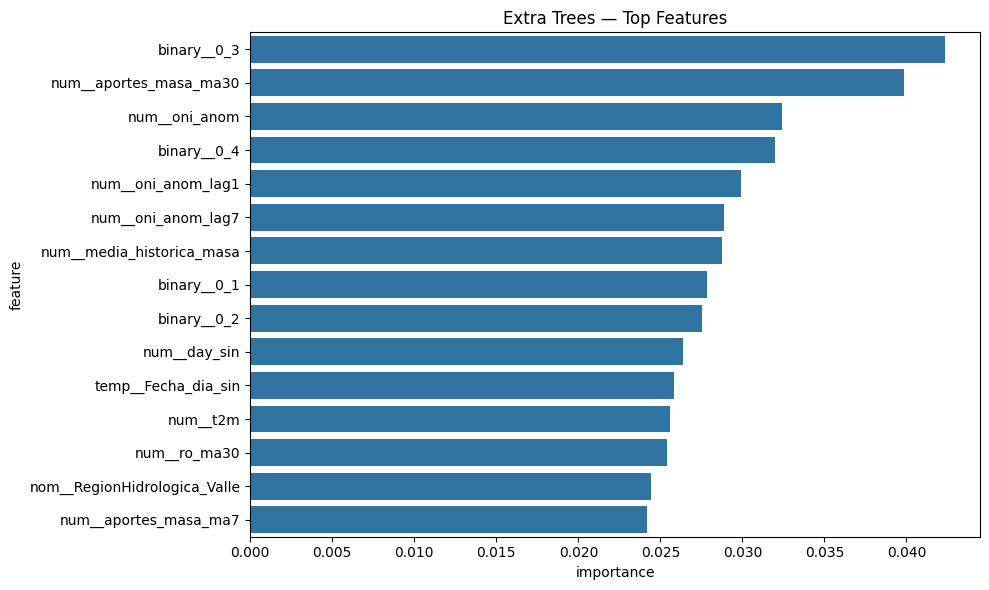

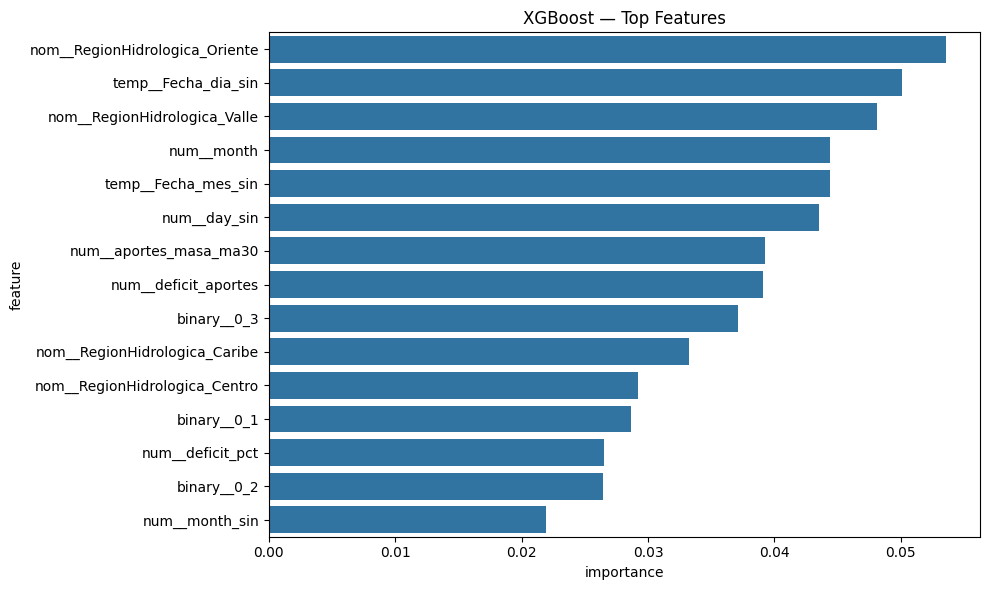

In [63]:
# =========================================================
# EVALUACIÓN AVANZADA — TODOS LOS MODELOS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# PREDICCIONES
# =========================================================

rf_preds = rf_model.predict(X_test)

et_preds = extra_trees_model.predict(X_test)

xgb_preds = xgb_model.predict(X_test)

# =========================================================
# BASELINE NAIVE
# =========================================================
# Predicción = valor anterior observado

naive_preds = y_test.shift(1)

valid_mask = naive_preds.notnull()

# =========================================================
# SERIES ALINEADAS
# =========================================================

y_eval = y_test.loc[valid_mask]

naive_eval = naive_preds.loc[valid_mask]

rf_eval = pd.Series(
    rf_preds,
    index=y_test.index
).loc[valid_mask]

et_eval = pd.Series(
    et_preds,
    index=y_test.index
).loc[valid_mask]

xgb_eval = pd.Series(
    xgb_preds,
    index=y_test.index
).loc[valid_mask]

# =========================================================
# MASE
# =========================================================

naive_scale = np.mean(
    np.abs(
        y_eval.values[1:]
        - y_eval.values[:-1]
    )
)

def mase(y_true, y_pred, scale):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    return mae / scale

# =========================================================
# MÉTRICAS EXTRA
# =========================================================

extra_metrics = {

    "Random Forest": {
        "MASE": mase(
            y_eval,
            rf_eval,
            naive_scale
        )
    },

    "Extra Trees": {
        "MASE": mase(
            y_eval,
            et_eval,
            naive_scale
        )
    },

    "XGBoost": {
        "MASE": mase(
            y_eval,
            xgb_eval,
            naive_scale
        )
    },

    "Baseline Decision Tree": {
        "MASE": np.nan
    }
}

# =========================================================
# COPIA DE RESULTADOS BASE
# =========================================================

model_results_extended = (
    model_results_df.copy()
)

# =========================================================
# AGREGAR MASE
# =========================================================

model_results_extended["MASE"] = (
    model_results_extended["experiment"]
    .apply(
        lambda x:
            extra_metrics[x]["MASE"]
            if x in extra_metrics
            else np.nan
    )
)

# =========================================================
# AGREGAR BASELINE NAIVE
# =========================================================

naive_row = pd.DataFrame([{

    "experiment": "Naive Baseline",

    "rmse": np.sqrt(
        mean_squared_error(
            y_eval,
            naive_eval
        )
    ),

    "mae": mean_absolute_error(
        y_eval,
        naive_eval
    ),

    "r2": r2_score(
        y_eval,
        naive_eval
    ),

    "MASE": mase(
        y_eval,
        naive_eval,
        naive_scale
    ),
}])

# =========================================================
# CONCATENAR
# =========================================================

model_results_extended = pd.concat(
    [
        model_results_extended,
        naive_row
    ],
    ignore_index=True
)

# =========================================================
# ORDENAR
# =========================================================

model_results_extended = (
    model_results_extended
    .sort_values("rmse")
)

# =========================================================
# RESULTADOS
# =========================================================

print_section(
    "RESULTADOS — MODELOS"
)

display(model_results_extended)

# =========================================================
# COMPARACIÓN DE MÉTRICAS
# =========================================================

metricas_plot = [
    "rmse",
    "mae",
    "MASE"
]

for metric in metricas_plot:

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    sns.barplot(
        data=model_results_extended,
        x="experiment",
        y=metric,
        ax=ax
    )

    ax.set_title(
        f"Comparación de {metric.upper()}"
    )

    ax.set_xlabel("Modelo")

    plt.xticks(rotation=15)

    plt.tight_layout()

    plt.show()

# =========================================================
# SELECCIONAR 5 EMBALSES
# =========================================================

embalses_plot = (
    X_test_raw.loc[
        y_eval.index,
        "CodigoEmbalse"
    ]
    .drop_duplicates()
    .head(5)
    .tolist()
)

print("Embalses seleccionados:")
print(embalses_plot)

# =========================================================
# RANGO TEMPORAL
# =========================================================

plot_start = "2024-10-01"
plot_end   = "2024-10-15"

# =========================================================
# FECHAS Y EMBALSES ALINEADOS
# =========================================================

test_dates = X_test_raw.loc[
    y_eval.index,
    "Fecha"
]

test_embalses = X_test_raw.loc[
    y_eval.index,
    "CodigoEmbalse"
]

# =========================================================
# PREDICCIONES
# =========================================================

predictions_dict = {

    "Naive Baseline": naive_eval,

    "Random Forest": rf_eval,

    "Extra Trees": et_eval,

    "XGBoost": xgb_eval,
}

# =========================================================
# LOOP POR EMBALSE
# =========================================================

for embalse in embalses_plot:

    print("=" * 80)
    print(f"EMBALSE: {embalse}")
    print("=" * 80)

    embalse_mask = (
    test_embalses == embalse
    )

    plot_dates = test_dates.loc[
        embalse_mask
    ]

    plot_real = y_eval.loc[
        embalse_mask
    ]

    # =====================================================
    # REAL VS PREDICCIÓN
    # =====================================================

    for model_name, preds_all in predictions_dict.items():

        preds = preds_all.loc[
            plot_real.index
        ]

        fig, ax = plt.subplots(
            figsize=(14, 5)
        )

        ax.plot(
            plot_dates,
            plot_real,
            label="Real",
            linewidth=2
        )

        ax.plot(
            plot_dates,
            preds,
            label=model_name,
            linewidth=1.7
        )

        ax.set_title(
            f"{model_name} — {embalse}"
        )

        ax.set_xlabel("Fecha")

        ax.set_ylabel(TARGET)

        ax.legend()

        plt.tight_layout()

        plt.show()

    # =====================================================
    # RESIDUALES
    # =====================================================

    for model_name, preds_all in predictions_dict.items():

        preds = preds_all.loc[
            plot_real.index
        ]

        residuals = (
            plot_real - preds
        )

        fig, ax = plt.subplots(
            figsize=(14, 4)
        )

        ax.plot(
            plot_dates,
            residuals,
            linewidth=1.2
        )

        ax.axhline(
            0,
            linestyle="--"
        )

        ax.set_title(
            f"{model_name} — Residuales — {embalse}"
        )

        ax.set_xlabel("Fecha")

        ax.set_ylabel("Residual")

        plt.tight_layout()

        plt.show()

    # =====================================================
    # DISTRIBUCIÓN DE ERRORES
    # =====================================================

    for model_name, preds_all in predictions_dict.items():

        preds = preds_all.loc[
            plot_real.index
        ]

        residuals = (
            plot_real - preds
        )

        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        sns.histplot(
            residuals,
            bins=15,
            kde=True,
            ax=ax
        )

        ax.set_title(
            f"{model_name} — Distribución de Residuales — {embalse}"
        )

        ax.set_xlabel("Residual")

        plt.tight_layout()

        plt.show()

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================

models_dict = {
    "Random Forest": rf_model,
    "Extra Trees": extra_trees_model,
    "XGBoost": xgb_model,
}

for model_name, pipeline in models_dict.items():

    regressor = pipeline.named_steps[
        "regressor"
    ]

    feature_names = pipeline.named_steps[
        "preprocess"
    ].get_feature_names_out()

    importances = pd.DataFrame({

        "feature": feature_names,

        "importance":
            regressor.feature_importances_
    })

    importances = (
        importances
        .sort_values(
            "importance",
            ascending=False
        )
        .head(15)
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    sns.barplot(
        data=importances,
        x="importance",
        y="feature",
        ax=ax
    )

    ax.set_title(
        f"{model_name} — Top Features"
    )

    plt.tight_layout()

    plt.show()

Embalse seleccionado: AGREGADO_BOGOTA


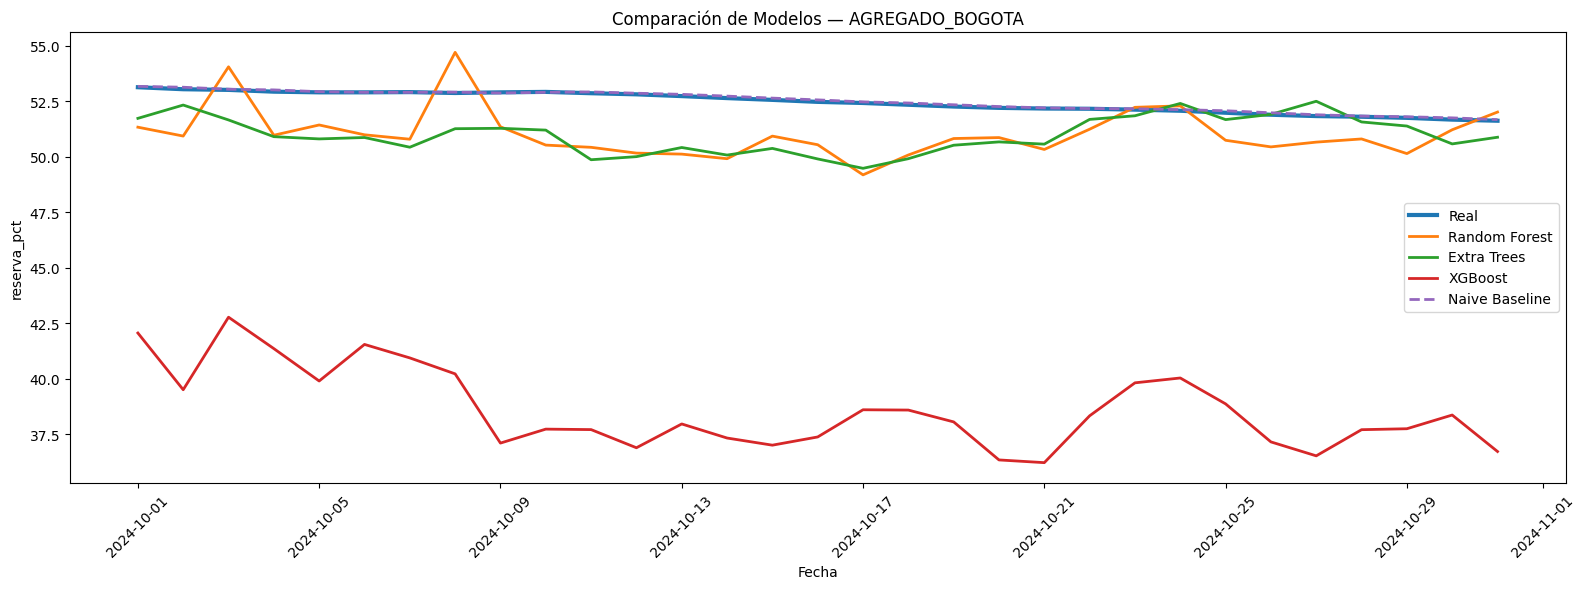

In [66]:
# =========================================================
# COMPARACIÓN DE TODOS LOS MODELOS VS REAL
# EN UN SOLO GRÁFICO
# =========================================================


# =========================================================
# EMBALSE A VISUALIZAR
# =========================================================

embalse_plot = embalses_plot[0]

print(f"Embalse seleccionado: {embalse_plot}")

# =========================================================
# RANGO TEMPORAL
# =========================================================

plot_start = "2024-10-01"
plot_end   = "2024-10-31"

# =========================================================
# FECHAS Y EMBALSES
# =========================================================

test_dates = X_test_raw.loc[
    y_eval.index,
    "Fecha"
]

test_embalses = X_test_raw.loc[
    y_eval.index,
    "CodigoEmbalse"
]

# =========================================================
# FILTRO
# =========================================================

plot_mask = (

    (test_dates >= plot_start)
    &
    (test_dates <= plot_end)
    &
    (test_embalses == embalse_plot)

)

plot_dates = test_dates.loc[
    plot_mask
]

plot_real = y_eval.loc[
    plot_mask
]

# =========================================================
# PREDICCIONES
# =========================================================

plot_rf = rf_eval.loc[
    plot_real.index
]

plot_et = et_eval.loc[
    plot_real.index
]

plot_xgb = xgb_eval.loc[
    plot_real.index
]

plot_naive = naive_eval.loc[
    plot_real.index
]

# =========================================================
# GRÁFICA
# =========================================================

fig, ax = plt.subplots(
    figsize=(16, 6)
)

# REAL

ax.plot(
    plot_dates,
    plot_real,
    label="Real",
    linewidth=3
)

# RANDOM FOREST

ax.plot(
    plot_dates,
    plot_rf,
    label="Random Forest",
    linewidth=2
)

# EXTRA TREES

ax.plot(
    plot_dates,
    plot_et,
    label="Extra Trees",
    linewidth=2
)

# XGBOOST

ax.plot(
    plot_dates,
    plot_xgb,
    label="XGBoost",
    linewidth=2
)

# NAIVE

ax.plot(
    plot_dates,
    plot_naive,
    label="Naive Baseline",
    linewidth=2,
    linestyle="--"
)

# =========================================================
# ESTÉTICA
# =========================================================

ax.set_title(
    f"Comparación de Modelos — {embalse_plot}"
)

ax.set_xlabel("Fecha")

ax.set_ylabel(TARGET)

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()